# 02 · Exploratory Data Analysis

**Goal:** describe the training data and find the patterns that justify the features. This is **⅓ of the grade**.

> *"Conduct exploratory data analysis of the Training Set. Provide an overview of the data set and underlying patterns you may identify… Document and justify any conclusions you draw."*

| | |
|---|---|
| **Inputs** | `clean/inspections_clean.pkl`, `clean/violation_codes_clean.csv`, `clean/data_quality_log.csv`, `clean/column_roles.csv` (from 01), `raw/inspector_acronym_lookup.csv` |
| **Outputs** | `clean/split.csv` (train/holdout assignment used by every later notebook), `figures/eda_*.png` |

**Rules for this notebook**
1. **The holdout is set aside first** (section 2) and is only checked structurally: rows, restaurants, overlap and date ranges. Every rate, chart and conclusion after that uses **training rows only**.
2. **Rates come with their sample size and a 95% interval.** A restaurant can appear up to 6 times, so the intervals are **clustered by restaurant**: approximate Wilson intervals computed on an effective sample size that accounts for repeat inspections. The `design_effect` column is the variance inflation from repeats (1.0 = none); the interval widens by roughly its square root.
3. **Associations are hypotheses for 03 and 04, not causal claims or final feature selections.** Groups with fewer than about 100 rows are reported but not interpreted.
4. **Missing-data rules from 01 apply throughout.**
   - Violation counts come from `n_violations`, never from the length of `violation_ids`.
   - Summaries that need the full list (severity counts, totals, "no hazard") exist only when `violation_list_complete = 1` and are unknown otherwise.
   - A hazard named in the first/second/third codes counts as present even without a full list.
5. **p-values are unadjusted exploratory diagnostics.** The chi-square tests treat inspections as independent (they don't adjust for repeat inspections of the same restaurant) and aren't corrected for the many comparisons in this notebook. A p near 0.05 is weak evidence, and a large p means no clear difference was detected, not that there is none.

## 0. Setup

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

ROOT = Path.cwd()
RAW = ROOT / "raw"
CLEAN = ROOT / "clean"
FIG = ROOT / "figures"

TARGET = "NEXT_INSPECTION_GRADE_C_OR_BELOW"
GROUP_KEY = "RESTAURANT_SERIAL_NUMBER"
TIME_COL = "INSPECTION_TIME"

HOLDOUT_SHARE = 0.20  # share of restaurants held out (section 2)
HOLDOUT_SEED = 42     # fixed before any analysis; never tuned

In [2]:
# One chart style for every figure in the report and the deck: a single accent color for one series, a fixed
# color order when comparing series, a light grid and axes, and text in ink colors (never in the series color).
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow, always in this order

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
    "lines.linewidth": 2, "legend.frameon": False,
})
SAVED_FIGURES = []


def save_fig(fig, name):
    """Save a figure to figures/<name>.png for the report and the deck."""
    FIG.mkdir(exist_ok=True)
    fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")
    SAVED_FIGURES.append(name)

## 1. Load the cleaned data

In [3]:
if not (CLEAN / "inspections_clean.pkl").exists():
    raise FileNotFoundError("clean/inspections_clean.pkl not found. Run 01_data_cleaning.ipynb first.")

df = pd.read_pickle(CLEAN / "inspections_clean.pkl")
df[TARGET] = df[TARGET].astype(int)
codes = pd.read_csv(CLEAN / "violation_codes_clean.csv")
dq_log = pd.read_csv(CLEAN / "data_quality_log.csv")
roles = pd.read_csv(CLEAN / "column_roles.csv")

contract = {
    f"{TIME_COL} is a datetime": pd.api.types.is_datetime64_any_dtype(df[TIME_COL]),
    "violation_ids holds lists of IDs (None where the list is unavailable)":
        df["violation_ids"].map(lambda v: v is None or isinstance(v, list)).all(),
    "n_violations and violation_list_complete present": {"n_violations", "violation_list_complete"} <= set(df.columns),
    "codes has Violation_ID, Violation_Demerits, severity, severity_rank":
        {"Violation_ID", "Violation_Demerits", "severity", "severity_rank"} <= set(codes.columns),
}
for name, ok in contract.items():
    print(("✅ " if ok else "❌ ") + name)
if not all(contract.values()):
    raise ValueError("The 01_data_cleaning output is missing something this notebook needs (see ❌ above).")
print(f"{len(df):,} rows loaded")

✅ INSPECTION_TIME is a datetime
✅ violation_ids holds lists of IDs (None where the list is unavailable)
✅ n_violations and violation_list_complete present
✅ codes has Violation_ID, Violation_Demerits, severity, severity_rank
35,000 rows loaded


## 2. Holdout design (decided before looking at any patterns)

**The use case:** *"predict the outcome of a restaurant's next inspection."* The holdout should estimate how the model will do on inspections it never saw, without any information leaking in through repeat restaurants.

**Decision: hold out 20% of restaurants at random, grouped by `RESTAURANT_SERIAL_NUMBER`, with `random_state = 42`.** Every inspection of a held-out restaurant goes to the holdout, so no restaurant is in both sets. Cross-validation in 04 uses the same grouping (`GroupKFold` by restaurant), so training, tuning and the final test all follow one rule.

**Why grouped rather than by time**
- **Restaurants repeat** (up to 6 inspections each). With a random row split, a restaurant's other inspections would sit in training, and its fixed attributes would let a model recognize it rather than learn general risk.
- **A clean time split isn't available.** The data has no date for the "next inspection" each label describes. With a cutoff date, the labels of the last training inspections could describe inspections *after* the cutoff, and nothing here can detect that. Also, 317 rows (0.9%) have no inspection date at all.
- **A time split wouldn't remove restaurant overlap.** The same restaurants are inspected across all years, so it would also need restaurant grouping.

**What this holdout does not show:** it measures performance on *unseen restaurants within 2020–2026*. It doesn't independently show how well the model carries over to a *future* period. In 04, a backward-looking check inside the training folds (fit on earlier years, check on later years) can address that without touching the holdout.

The assignment is saved to `clean/split.csv` (row number, restaurant ID, split). This notebook rebuilds it from the fixed seed and refuses to continue if an existing file disagrees.

In [4]:
def make_split(frame):
    """'train' / 'holdout' per row: HOLDOUT_SHARE of restaurants, chosen at random with HOLDOUT_SEED."""
    splitter = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_SHARE, random_state=HOLDOUT_SEED)
    _, holdout_idx = next(splitter.split(frame, groups=frame[GROUP_KEY]))
    labels = np.full(len(frame), "train", dtype=object)
    labels[holdout_idx] = "holdout"
    return pd.Series(labels, index=frame.index, name="split")


split_table = pd.DataFrame({GROUP_KEY: df[GROUP_KEY], "split": make_split(df)})
split_path = CLEAN / "split.csv"
if split_path.exists():
    saved = pd.read_csv(split_path, index_col="row")
    if not (saved.index.equals(split_table.index) and saved[GROUP_KEY].equals(split_table[GROUP_KEY])
            and saved["split"].equals(split_table["split"])):
        raise ValueError("clean/split.csv disagrees with the documented policy. Investigate before replacing it.")
    print("clean/split.csv exists and matches the policy: reused unchanged")
else:
    split_table.to_csv(split_path, index_label="row")
    print("saved clean/split.csv")
split = split_table["split"]

# Structural checks only: no target statistics on the holdout
structure = df.groupby(split).agg(rows=(GROUP_KEY, "size"), restaurants=(GROUP_KEY, "nunique"),
                                  rows_without_date=(TIME_COL, lambda s: s.isna().sum()),
                                  first_inspection=(TIME_COL, "min"), last_inspection=(TIME_COL, "max"))
overlap = set(df.loc[split.eq("train"), GROUP_KEY]) & set(df.loc[split.eq("holdout"), GROUP_KEY])
print(f"restaurants in both sets: {len(overlap)} | holdout share of rows: {split.eq('holdout').mean():.1%}")
structure

clean/split.csv exists and matches the policy: reused unchanged
restaurants in both sets: 0 | holdout share of rows: 19.9%


,rows,restaurants,rows_without_date,first_inspection,last_inspection
split,,,,,
holdout,6964,3981,63,2020-04-01 20:25:00,2026-09-18 14:55:00
train,28036,15921,254,2020-04-01 13:40:00,2026-09-18 22:50:00


In [5]:
train = df.loc[split.eq("train")].copy()  # every analysis below uses training rows only
N_ROWS_ALL = len(df)
del df                                     # the full table is not used again in this notebook
BASE_RATE = train[TARGET].mean()
print(f"training rows: {len(train):,} | restaurants: {train[GROUP_KEY].nunique():,} | base rate: {BASE_RATE:.2%}")

training rows: 28,036 | restaurants: 15,921 | base rate: 23.67%


## 3. Helpers

In [6]:
def rate_by(frame, by, min_n=30):
    """Target rate per group: n, positives, rate, a 95% interval clustered by restaurant, lift over the training
    average, and the design effect (the variance inflation from repeat inspections; 1 = none). The interval is an
    approximate Wilson interval on the effective sample size n / design_effect, so it widens by about the square
    root of the design effect.
    `by` is a column name or a Series aligned with `frame`; rows where it is missing are left out."""
    key = frame[by] if isinstance(by, str) else by
    d = pd.DataFrame({"g": key, "y": frame[TARGET], "c": frame[GROUP_KEY]}).dropna(subset=["g"])
    agg = d.groupby("g", observed=True)["y"].agg(n="size", positives="sum")
    p = agg["positives"] / agg["n"]
    per_restaurant = d.groupby(["g", "c"], observed=True)["y"].agg(s="sum", m="size").reset_index()
    resid = per_restaurant["s"] - per_restaurant["g"].map(p).astype(float) * per_restaurant["m"]
    k = per_restaurant.groupby("g", observed=True).size()
    var = resid.pow(2).groupby(per_restaurant["g"], observed=True).sum() * k / (k - 1).clip(lower=1) / agg["n"] ** 2
    binomial = p * (1 - p) / agg["n"]
    deff = (var / binomial).where(binomial > 0, 1.0).clip(lower=1.0)
    n_eff, z = agg["n"] / deff, 1.96
    centre = (p + z**2 / (2 * n_eff)) / (1 + z**2 / n_eff)
    half = z * np.sqrt(p * (1 - p) / n_eff + z**2 / (4 * n_eff**2)) / (1 + z**2 / n_eff)
    out = agg.assign(rate=p, ci_low=centre - half, ci_high=centre + half, lift=p / BASE_RATE, design_effect=deff)
    out.index.name = getattr(key, "name", None) or "group"
    return out[out["n"] >= min_n]


def quintiles(values):
    """Quintile bins of a whole-number column, labelled with their actual ranges (e.g. '14-34')."""
    bins = pd.qcut(values, 5, duplicates="drop")
    labels = {iv: f"{int(np.floor(iv.left)) + 1}-{int(iv.right)}" for iv in bins.cat.categories}
    return bins.cat.rename_categories(labels)


def capped(values, cap, name):
    """Whole-number counts as ordered categories '0', '1', ..., 'cap+' (missing stays missing)."""
    labels = [str(i) for i in range(cap)] + [f"{cap}+"]
    v = values.clip(upper=cap).astype("Int64")
    text = v.map(lambda x: None if pd.isna(x) else (f"{cap}+" if x == cap else str(int(x))))
    return pd.Series(pd.Categorical(text, categories=labels, ordered=True), index=values.index, name=name)


def show(table, digits=3):
    """Rate table rounded for display."""
    return table.round({"rate": digits, "ci_low": digits, "ci_high": digits, "lift": 2, "design_effect": 2})


def homogeneity_p(by):
    """Unadjusted chi-square p-value for "the target rate is the same in every group" (training rows; missing
    groups dropped). It treats inspections as independent, ignoring repeat inspections of a restaurant, and isn't
    corrected for multiple comparisons: an exploratory diagnostic, not a formal test."""
    tab = pd.crosstab(by, train[TARGET])
    return chi2_contingency(tab)[1]


def plot_rate(table, title, xlabel="", horizontal=False, ax=None):
    """Bars of the target rate per group (from rate_by) with 95% intervals; the gray line is the training average."""
    if ax is None:
        size = (7.5, max(2.4, 0.32 * len(table) + 1.2)) if horizontal else (max(6, 0.65 * len(table) + 2), 3.6)
        _, ax = plt.subplots(figsize=size)
    pos = np.arange(len(table))
    err = np.vstack([table["rate"] - table["ci_low"], table["ci_high"] - table["rate"]])
    names = table.index.astype(str)
    style = {"color": SERIES[0], "ecolor": INK_2, "error_kw": {"linewidth": 1}}
    if horizontal:
        ax.barh(pos, table["rate"], height=0.6, xerr=err, **style)
        ax.set_yticks(pos, [f"{k}  (n={n:,})" for k, n in zip(names, table["n"])])
        ax.invert_yaxis()
        ax.axvline(BASE_RATE, color=MUTED, linewidth=1)
        ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        ax.grid(axis="y", visible=False)
        ax.set_xlabel(f"next inspection graded C or below (gray line = average {BASE_RATE:.1%})")
    else:
        ax.bar(pos, table["rate"], width=0.6, yerr=err, **style)
        ax.set_xticks(pos, [f"{k}\nn={n:,}" for k, n in zip(names, table["n"])])
        ax.axhline(BASE_RATE, color=MUTED, linewidth=1)
        ax.annotate(f"average\n{BASE_RATE:.1%}", xy=(1, BASE_RATE), xycoords=("axes fraction", "data"),
                    xytext=(4, 0), textcoords="offset points", ha="left", va="center", color=INK_2, fontsize=9)
        ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        ax.grid(axis="x", visible=False)
        ax.set_ylabel("next inspection C or below")
        ax.set_xlabel(xlabel)
    ax.set_title(title)
    return ax


def plot_two_groups(table_a, table_b, label_a, label_b, title, xlabel, ax=None):
    """Two rate_by tables over the same x categories as lines with 95% bands (legend + end labels)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3.8))
    for t, label, color in [(table_a, label_a, SERIES[0]), (table_b, label_b, SERIES[1])]:
        x = np.arange(len(t))
        ax.fill_between(x, t["ci_low"], t["ci_high"], color=color, alpha=0.12, linewidth=0)
        ax.plot(x, t["rate"], color=color, marker="o", markersize=6, label=label)
        ax.annotate(label, xy=(x[-1], t["rate"].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_xticks(np.arange(len(table_a)), table_a.index.astype(str))
    ax.axhline(BASE_RATE, color=MUTED, linewidth=1)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_ylim(0, None)
    ax.set(title=title, xlabel=xlabel, ylabel="next inspection C or below")
    ax.legend(loc="upper left")
    return ax


def univariate_auc(frame, columns):
    """Screening: how well each column alone ranks the target (0.5 = no signal; either direction counts),
    with the number of rows that have a value."""
    rows = []
    for col in columns:
        x = pd.to_numeric(frame[col], errors="coerce")
        ok = x.notna()
        if ok.sum() < 100 or x[ok].nunique() < 2:
            continue
        auc = roc_auc_score(frame.loc[ok, TARGET], x[ok])
        rows.append({"column": col, "auc": round(auc, 3), "strength": round(max(auc, 1 - auc), 3),
                     "rows_used": int(ok.sum()), "missing": int((~ok).sum()),
                     "direction": "higher → more C" if auc >= 0.5 else "higher → fewer C"})
    return pd.DataFrame(rows).set_index("column").sort_values("strength", ascending=False)


DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])


def plot_corr(frame, columns, title, label_above=0.5):
    """Spearman correlation heatmap (pairwise complete rows); only |r| >= label_above is written in the cells."""
    corr = frame[columns].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
    k = len(columns)
    fig, ax = plt.subplots(figsize=(0.55 * k + 3.5, 0.5 * k + 1.5))
    im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
    ax.set_xticks(range(k), columns, rotation=90)
    ax.set_yticks(range(k), columns)
    ax.grid(False)
    for i in range(k):
        for j in range(k):
            r = corr.iat[i, j]
            if i != j and abs(r) >= label_above:
                ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(r) > 0.7 else INK)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
    ax.set_title(title)
    return fig, corr


# Violation-list helpers that follow the missing-data rule (same semantics as 03)
SEV = codes.set_index("Violation_ID")["severity"].to_dict()
RANK = codes.set_index("Violation_ID")["severity_rank"].to_dict()
DEM = codes.set_index("Violation_ID")["Violation_Demerits"].to_dict()
RANK_NAME = {0: "No demerits", 1: "Non-Major", 2: "Major", 3: "Critical", 4: "Imminent hazard"}
COMPLETE = train["violation_list_complete"].eq(1)
NAMED = train[["first_violation_id", "second_violation_id", "third_violation_id"]]


def from_complete_lists(summarize):
    """summarize(list of IDs) for complete lists only; NaN where the list is unavailable or incomplete."""
    out = pd.Series(np.nan, index=train.index)
    out[COMPLETE] = train.loc[COMPLETE, "violation_ids"].map(summarize).astype(float)
    return out


def severity_status(level):
    """'present' if a code of this severity is confirmed (list or named first/second/third codes), 'absent' only
    with a complete list, otherwise 'unknown'."""
    in_list = train["violation_ids"].map(lambda ids: isinstance(ids, list) and any(SEV.get(i) == level for i in ids))
    in_named = NAMED.apply(lambda col: col.map(SEV).eq(level)).any(axis=1)
    return pd.Series(np.where(in_list | in_named, "present", np.where(COMPLETE, "absent", "unknown")),
                     index=train.index)

## 4. Overview of the training set

In [7]:
per_restaurant = train.groupby(GROUP_KEY).size()
overview = pd.Series({
    "training rows": f"{len(train):,} of {N_ROWS_ALL:,}",
    "restaurants": f"{train[GROUP_KEY].nunique():,}",
    "restaurants with 2+ inspections": f"{(per_restaurant > 1).sum():,} ({(per_restaurant > 1).mean():.0%})",
    "rows from repeat restaurants": f"{per_restaurant[per_restaurant > 1].sum():,} ({per_restaurant[per_restaurant > 1].sum() / len(train):.0%})",
    "inspection dates": f"{train[TIME_COL].min():%d %b %Y} to {train[TIME_COL].max():%d %b %Y} ({train[TIME_COL].isna().sum()} rows undated)",
    "next inspection C or below": f"{train[TARGET].sum():,} rows ({BASE_RATE:.2%})",
})
print(overview.to_string())
print("\ninspections per restaurant:", per_restaurant.value_counts().sort_index().to_dict())
show(rate_by(train.assign(all_training_rows="all"), "all_training_rows"))

training rows                                                   28,036 of 35,000
restaurants                                                               15,921
restaurants with 2+ inspections                                      7,179 (45%)
rows from repeat restaurants                                        19,294 (69%)
inspection dates                   01 Apr 2020 to 18 Sep 2026 (254 rows undated)
next inspection C or below                                   6,637 rows (23.67%)



inspections per restaurant: {1: 8742, 2: 3932, 3: 2064, 4: 788, 5: 284, 6: 111}


,n,positives,rate,ci_low,ci_high,lift,design_effect
all_training_rows,,,,,,,
all,28036,6637,0.237,0.232,0.242,1.0,1.04


quarterly rates range 21.3%–25.9%; same rate in every year? unadjusted chi-square p = 0.39


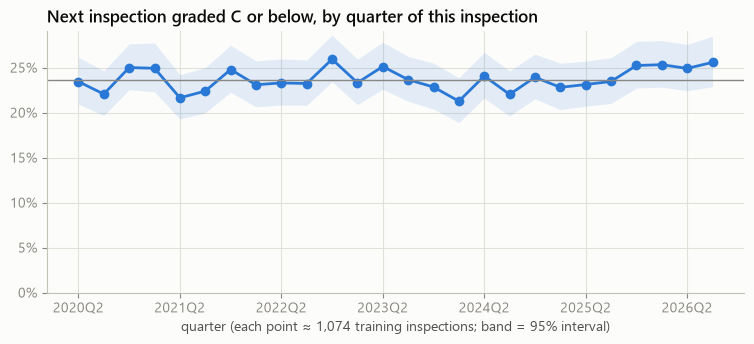

In [8]:
quarterly = rate_by(train, train[TIME_COL].dt.to_period("Q").rename("quarter"))
x = np.arange(len(quarterly))
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.fill_between(x, quarterly["ci_low"], quarterly["ci_high"], color=SERIES[0], alpha=0.12, linewidth=0)
ax.plot(x, quarterly["rate"], color=SERIES[0], marker="o", markersize=6)
ax.axhline(BASE_RATE, color=MUTED, linewidth=1)
ax.set_xticks(x[::4], quarterly.index.astype(str)[::4])
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0, None)
ax.set(title="Next inspection graded C or below, by quarter of this inspection",
       xlabel=f"quarter (each point ≈ {quarterly['n'].median():,.0f} training inspections; band = 95% interval)")
save_fig(fig, "eda_target_by_quarter")
print(f"quarterly rates range {quarterly['rate'].min():.1%}–{quarterly['rate'].max():.1%}; "
      f"same rate in every year? unadjusted chi-square p = {homogeneity_p(train[TIME_COL].dt.year):.2f}")

**Interpretation**
- **Size and dependence:** 28,036 training inspections from 15,921 restaurants. 45% of restaurants appear more than once, and their rows make up 69% of training. The overall rate's design effect is 1.04: repeat inspections inflate its variance by about 4%, which widens its interval by only about 2% (√1.04 ≈ 1.02). So for the overall rate, repeat inspections add little dependence. The clustering is still kept in every interval below.
- **Imbalance:** 23.7% of next inspections are graded C or below. That's imbalanced but not rare, which matters for the metric choice in 04 (Average Precision and capture rates alongside ROC-AUC).
- **No time trend:** quarterly rates stay between 21.3% and 25.9%, and every quarterly interval overlaps the average. A year-by-year chi-square test finds no clear difference (unadjusted p = 0.39). Calendar time doesn't look like a useful predictor, and the stability supports the grouped holdout design.

In [9]:
candidates = roles.loc[roles["role"].eq("feature_candidate"), "column"].tolist()
missing = pd.DataFrame({"missing_rows": train[candidates].isna().sum(),
                        "missing_share": train[candidates].isna().mean().round(4)})
missing = missing[missing["missing_rows"] > 0].sort_values("missing_rows", ascending=False)
print(f"{len(candidates)} feature candidates; {len(missing)} have missing values; "
      f"blank comments: {train['comment_fragments'].map(len).eq(0).sum():,} rows ({train['comment_fragments'].map(len).eq(0).mean():.1%})")
missing

37 feature candidates; 26 have missing values; blank comments: 2,272 rows (8.1%)


,missing_rows,missing_share
MEDIAN_EMPLOYEE_AGE,255,0.0091
INSPECTION_TIME,254,0.0091
CURRENT_DEMERITS,252,0.0090
EMPLOYEE_COUNT,252,0.0090
MEDIAN_EMPLOYEE_TENURE,249,0.0089
RESTAURANT_LOCATION,249,0.0089
INSPECTION_DEMERITS,246,0.0088
violation_ids,245,0.0087
RESTAURANT_CATEGORY,177,0.0063
CURRENT_GRADE,164,0.0058


**Interpretation**
- **Missingness is low everywhere:** at most 0.9% of training rows for any candidate column (employee fields, inspection date, demerits, location). That's mostly the result of 01 turning junk and impossible values into missing ones and *not* filling them from other inspections.
- **The violation list is unavailable for 245 rows (0.9%),** but `n_violations` is missing for only 6 because it comes from `NUMBER_OF_VIOLATIONS` on those rows.
- **Comments are blank on 8.1% of rows** (section 11).

Missing values like these are small enough for the 04 pipeline to impute inside each training fold, with missing-value indicators. Nothing needs to be dropped.

## 5. Data quality: what cleaning changed, and the assumptions behind it

In [10]:
print(f"{len(dq_log)} logged cleaning steps covering {dq_log['column'].nunique()} columns")
summary = (dq_log.groupby("column")["rows_affected"].sum().sort_values(ascending=False)
           .rename("rows affected (all 35,000 rows, before the split)"))
summary.head(20)

85 logged cleaning steps covering 42 columns


column
allergen_labeling_flag       35000
safety_certification_flag    35000
inspection_announced_flag    35000
LONGITUDE                    34918
RECORD_UPDATED                3508
Comments                      2787
LATITUDE/LONGITUDE             630
VIOLATIONS_RAW                 550
ZIP5                           469
CURRENT_GRADE                  422
INSPECTION_DEMERITS            393
NUMBER_OF_VIOLATIONS           368
FIRST_VIOLATION_DEMERITS       337
THIRD_VIOLATION_DEMERITS       325
EMPLOYEE_COUNT                 324
MEDIAN_EMPLOYEE_TENURE         320
INSPECTION_TIME                317
TOTAL_MAPPED_DEMERITS          317
SECOND_VIOLATION_TYPE          317
THIRD_VIOLATION_DESC           316
Name: rows affected (all 35,000 rows, before the split), dtype: int64

In [11]:
fixes = pd.Series({
    "'###' location placeholder left": int(train["RESTAURANT_LOCATION"].eq("###").sum()),
    "violation list unavailable (n_violations still known)": int((~COMPLETE & train["n_violations"].notna()).sum()),
    "violation count unknown": int(train["n_violations"].isna().sum()),
    "employee count missing (no cross-inspection fill)": int(train["EMPLOYEE_COUNT"].isna().sum()),
    "category missing (no cross-inspection fill)": int(train["RESTAURANT_CATEGORY"].isna().sum()),
    "RECORD_UPDATED missing (excluded from modeling)": int(train["RECORD_UPDATED"].isna().sum()),
}, name="training rows")
fixes.to_frame()

,training rows
'###' location placeholder left,0
violation list unavailable (n_violations still known),239
violation count unknown,6
employee count missing (no cross-inspection fill),252
category missing (no cross-inspection fill),177
RECORD_UPDATED missing (excluded from modeling),2808


**Interpretation**
- **The biggest repairs were cosmetic or structural:** whitespace and placeholder tokens across many columns, the missing minus sign on longitudes, and the junk and sentinel values in numeric columns.
- **The review fixes in 01 left their marks, and they're intended:**
  - No `###` locations remain.
  - 245 training rows have no usable violation list. 239 of them keep their count (from `NUMBER_OF_VIOLATIONS`) but have no severity breakdown; 6 have no count at all.
  - Employee and category values that couldn't be repaired from the same row stay missing, instead of being copied from other inspections of the restaurant.
- `RECORD_UPDATED` lost about 10% of its values (2,808 training rows), mostly dates after the assumed cutoff. It's excluded from modeling anyway.

**Assumptions carried into the analysis** (decided in 01, restated here because the conclusions depend on them):

| Assumption | Why | Effect on the analysis |
|---|---|---|
| Blank, `NULL`, `N/A`, `--`, `TBD`, `unknown`, `none` and location `###` mean missing | None is a real value anywhere in the file | Counts and rates use rows with real values only |
| Only A/B/C are valid grades; D, F, Z and Pending are missing | SNHD issues A/B/C, and the D/F/Z rows have A-level demerits | `CURRENT_GRADE` has 3 levels |
| Numeric values outside documented ranges are errors | Negatives, 999/9999/99999 placeholders, ages of 4 or 250 | Extreme values don't distort rates or correlations |
| 21 Sep 2026 is the data cutoff date (file date, not a verified delivery date) | Later timestamps are impossible | 3,190 `RECORD_UPDATED` values removed overall (unused for modeling) |
| ZIP prefixes `890xx`/`891xx` are plausible Clark County ZIPs | Plausibility only, not verification | Location analysis uses only plausible ZIPs |
| No value is borrowed from another inspection | Later inspections can't inform earlier ones | Slightly more missing values, no hidden leakage |
| Placeholder-only violation lists (`999`, `0`) are unavailable, not zero violations | These rows record 3+ violations elsewhere | Severity summaries are unknown for 245 training rows |
| `CURRENT_GRADE`/`CURRENT_DEMERITS` may be measured after this inspection | Their timing isn't documented | Reported in section 7 with a leakage caveat; 04 tests with and without |

## 6. The inspection itself: violations, severity, hazards and demerits

**Hypotheses from the first pass:**
- the C-or-below rate rises with the number of violations, and with the severity of the worst one;
- imminent health hazards (IHH) raise it despite carrying 0 demerits;
- the demerit measures disagree with each other.

rows used: 28,030 (rows with no count: 6); univariate AUC of n_violations: 0.626


,n,positives,rate,ci_low,ci_high,lift,design_effect
violations,,,,,,,
3,5330,817,0.153,0.144,0.163,0.65,1.00
4,6815,1237,0.182,0.173,0.191,0.77,1.01
5,5499,1196,0.217,0.207,0.229,0.92,1.01
6,3868,949,0.245,0.232,0.259,1.04,1.00
7,2466,725,0.294,0.276,0.312,1.24,1.00
8,1553,497,0.320,0.297,0.344,1.35,1.00
9,982,403,0.410,0.380,0.442,1.73,1.01
10,598,282,0.472,0.432,0.512,1.99,1.00
11,373,185,0.496,0.445,0.547,2.10,1.00


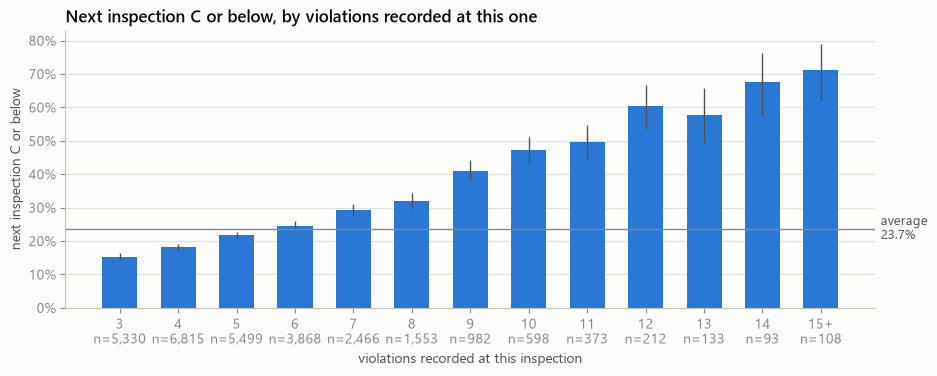

In [12]:
n_viol = capped(train["n_violations"], 15, "violations")
by_count = rate_by(train, n_viol)
plot_rate(by_count, "Next inspection C or below, by violations recorded at this one",
          xlabel="violations recorded at this inspection")
save_fig(plt.gcf(), "eda_rate_by_violations")
print(f"rows used: {int(by_count['n'].sum()):,} (rows with no count: {int(train['n_violations'].isna().sum())}); "
      f"univariate AUC of n_violations: {univariate_auc(train, ['n_violations'])['auc'].iat[0]}")
show(by_count)

**Interpretation**
- **The rate rises steadily with the number of violations:** 15.3% at 3 violations (n = 5,330) to 24.5% at 6, 47.2% at 10, and 71.3% at 15 or more (n = 108). The intervals don't overlap between neighboring low counts, and the climb has no visible plateau.
- **Uncertainty grows at high counts:** the 13 and 14 bars are within each other's intervals, because those groups have 93–133 rows.
- **For 03:** `n_violations` is a primary candidate, kept as a number (a smooth trend, so no binning). The 6 rows with no count stay missing.

rows used: 27,791 with a complete list (245 unavailable lists excluded)


,n,positives,rate,ci_low,ci_high,lift,design_effect
worst severity,,,,,,,
Non-Major,504,53,0.105,0.081,0.135,0.44,1.03
Major,7669,1103,0.144,0.136,0.152,0.61,1.02
Critical,18139,4986,0.275,0.268,0.281,1.16,1.01
Imminent hazard,1479,440,0.297,0.275,0.321,1.26,1.00


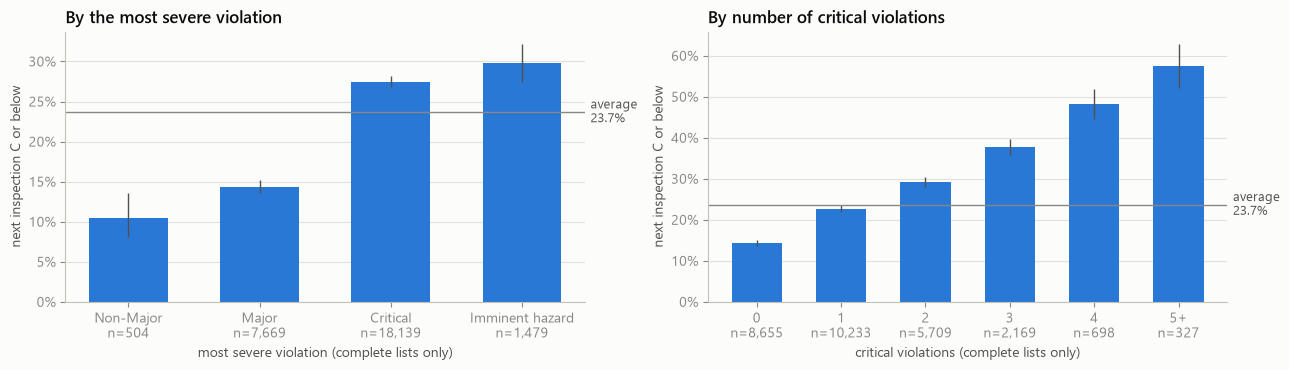

In [13]:
worst = from_complete_lists(lambda ids: max(RANK[i] for i in ids)).map(RANK_NAME).rename("worst severity")
critical = from_complete_lists(lambda ids: sum(SEV[i] == "Critical" for i in ids))
major = from_complete_lists(lambda ids: sum(SEV[i] == "Major" for i in ids))
non_major = from_complete_lists(lambda ids: sum(SEV[i] == "Non-Major" for i in ids))
ihh = severity_status("Imminent Health Hazard").rename("imminent health hazard")

order = ["Non-Major", "Major", "Critical", "Imminent hazard"]
by_worst = rate_by(train, worst).reindex([o for o in order if o in rate_by(train, worst).index])
by_critical = rate_by(train, capped(critical, 5, "critical violations"))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_rate(by_worst, "By the most severe violation", xlabel="most severe violation (complete lists only)", ax=axes[0])
plot_rate(by_critical, "By number of critical violations", xlabel="critical violations (complete lists only)",
          ax=axes[1])
fig.tight_layout()
save_fig(fig, "eda_rate_by_severity")
print(f"rows used: {int(COMPLETE.sum()):,} with a complete list ({int((~COMPLETE).sum())} unavailable lists excluded)")
show(by_worst)

In [14]:
counts_table = pd.concat({
    "critical": show(by_critical)[["n", "rate", "ci_low", "ci_high"]],
    "major": show(rate_by(train, capped(major, 5, "count")))[["n", "rate", "ci_low", "ci_high"]],
    "non-major": show(rate_by(train, capped(non_major, 5, "count")))[["n", "rate", "ci_low", "ci_high"]],
}, axis=1)
print("Rate by count of each severity (complete lists only):")
counts_table

Rate by count of each severity (complete lists only):


critical                       major                       non-major                      
          n   rate ci_low ci_high     n   rate ci_low ci_high         n   rate ci_low ci_high
0      8655  0.144  0.136   0.151  2966  0.213  0.199   0.228      2183  0.213  0.197   0.231
1     10233  0.227  0.219   0.236  8179  0.221  0.212   0.230      7232  0.205  0.196   0.215
2      5709  0.292  0.280   0.304  8690  0.226  0.217   0.235      8644  0.217  0.208   0.226
3      2169  0.378  0.357   0.398  5084  0.245  0.233   0.257      5503  0.240  0.229   0.251
4       698  0.483  0.446   0.520  1877  0.290  0.270   0.311      2569  0.287  0.270   0.305
5+      327  0.575  0.520   0.628   995  0.390  0.360   0.421      1660  0.423  0.400   0.447

In [15]:
print("Imminent health hazard: present if confirmed by the list or the named first/second/third codes;")
print("absent only with a complete list; otherwise unknown")
show(rate_by(train, ihh, min_n=1))

Imminent health hazard: present if confirmed by the list or the named first/second/third codes;
absent only with a complete list; otherwise unknown


,n,positives,rate,ci_low,ci_high,lift,design_effect
imminent health hazard,,,,,,,
absent,26312,6142,0.233,0.228,0.239,0.99,1.03
present,1486,443,0.298,0.275,0.322,1.26,1.00
unknown,238,52,0.218,0.171,0.275,0.92,1.01


**Interpretation**
- **Severity of the worst violation separates risk sharply** (27,791 rows with a complete list): Non-Major 10.5% (n = 504), Major 14.4%, Critical 27.5% and IHH 29.7% (n = 1,479).
- **The critical count is the strongest single count:** 14.4% with none, 22.7% with one, 29.2% with two, rising to 57.5% at five or more. Major and non-major counts barely move the rate until 4–5 of them. That pattern looks like a proxy for a high *total* rather than an effect of their own.
- **IHH:** a confirmed hazard raises the rate to 29.8% (n = 1,486), against 23.3% where a complete list shows none. That's real signal even though IHH codes carry 0 demerits, so a demerit total would miss it.
  - For 238 rows the hazard status is unknown (no usable list and no hazard among the named codes); their rate, 21.8% [17.1, 27.5], is not distinguishable from the average.
  - Treating those rows as "absent" would mislabel about 1% of the data, so they stay unknown.
- **For 03:**
  - worst-severity rank (or an is-critical / is-IHH pair);
  - the critical count;
  - an IHH flag with three states (1 / 0 / missing);
  - major and non-major counts only if they add something beyond `n_violations`.
  All are computed from complete lists only, together with `violation_list_complete`.

In [16]:
# Is the first listed code the most severe one (highest severity rank)? And does it carry the highest demerit
# value? The two differ because IHH codes rank highest but carry 0 demerits. Ties count as the maximum.
first_has_top_rank = from_complete_lists(lambda ids: RANK[ids[0]] == max(RANK[i] for i in ids))
first_has_top_demerits = from_complete_lists(lambda ids: DEM[ids[0]] == max(DEM[i] for i in ids))
dem_all = from_complete_lists(lambda ids: sum(DEM[i] for i in ids)).rename("demerits, all codes")
measures = train.assign(**{"demerits_all_codes": dem_all, "critical_count": critical, "worst_rank": worst.map(
    {v: k for k, v in RANK_NAME.items()})})
auc = univariate_auc(measures, ["n_violations", "critical_count", "worst_rank", "demerits_all_codes",
                                "INSPECTION_DEMERITS", "TOTAL_MAPPED_DEMERITS", "first_violation_demerits"])
print(f"the first listed code is the most severe one (highest severity rank) in {first_has_top_rank.mean():.1%} "
      f"of complete lists, and has the highest demerit value in {first_has_top_demerits.mean():.1%}")
print(measures[["INSPECTION_DEMERITS", "demerits_all_codes", "TOTAL_MAPPED_DEMERITS", "n_violations"]]
      .corr(method="spearman").round(2).to_string())
auc

the first listed code is the most severe one (highest severity rank) in 63.7% of complete lists, and has the highest demerit value in 52.1%
                       INSPECTION_DEMERITS  demerits_all_codes  TOTAL_MAPPED_DEMERITS  n_violations
INSPECTION_DEMERITS                   1.00                0.57                   0.12          0.67
demerits_all_codes                    0.57                1.00                   0.51          0.83
TOTAL_MAPPED_DEMERITS                 0.12                0.51                   1.00          0.16
n_violations                          0.67                0.83                   0.16          1.00


,auc,strength,rows_used,missing,direction
column,,,,,
first_violation_demerits,0.641,0.641,28034,2,higher → more C
demerits_all_codes,0.635,0.635,27791,245,higher → more C
n_violations,0.626,0.626,28030,6,higher → more C
critical_count,0.626,0.626,27791,245,higher → more C
INSPECTION_DEMERITS,0.604,0.604,27790,246,higher → more C
TOTAL_MAPPED_DEMERITS,0.590,0.590,27777,259,higher → more C
worst_rank,0.580,0.580,27791,245,higher → more C


rows used: 27,790 (missing: 246)


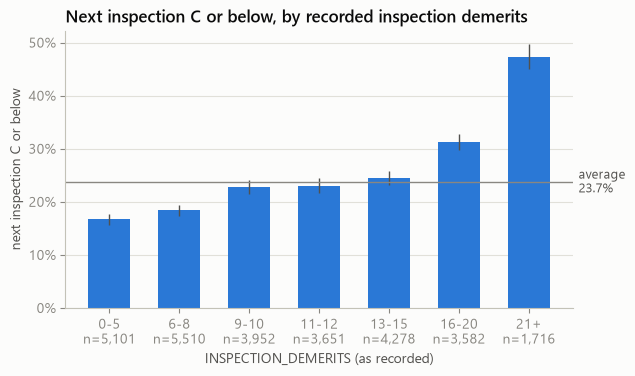

In [17]:
by_dem = rate_by(train, pd.cut(train["INSPECTION_DEMERITS"], [-1, 5, 8, 10, 12, 15, 20, 100],
                               labels=["0-5", "6-8", "9-10", "11-12", "13-15", "16-20", "21+"]).rename("demerits"))
plot_rate(by_dem, "Next inspection C or below, by recorded inspection demerits",
          xlabel="INSPECTION_DEMERITS (as recorded)")
save_fig(plt.gcf(), "eda_rate_by_inspection_demerits")
print(f"rows used: {int(by_dem['n'].sum()):,} (missing: {int(train['INSPECTION_DEMERITS'].isna().sum())})")

**Interpretation**
- **Three demerit measures, and they disagree.**
  - The recorded `INSPECTION_DEMERITS` correlates only moderately with the demerits implied by all the listed codes (Spearman 0.57).
  - `TOTAL_MAPPED_DEMERITS` (first three codes only) barely tracks the recorded value (0.12).
  - So the recorded demerits aren't simply the sum of the codes. They're a separately recorded number, and their rule is undocumented.
- **How each one ranks risk on its own:**
  - Code-implied total over all codes: AUC 0.635.
  - Recorded demerits: 0.604.
  - First-three total: 0.590.
  - First listed code's demerits: 0.641, the highest single measure. But the first code isn't always the most severe one: the output above shows how often it has the highest severity rank, and, less often, the highest demerit value. So its strength may partly reflect how codes were ordered when recorded. Treat it with caution; the critical count and worst severity don't depend on order.
  - Worst severity on its own scores lower (0.580) because it has only four levels, even though it separates the groups clearly.
- **The recorded demerits still carry a clear gradient:** 16.7% at 0–5 demerits up to 47.4% at 21 or more.
- **Overlap among the count measures is high:** the code-implied total correlates 0.83 with `n_violations`.
- **For 03:**
  - keep `n_violations`, the critical count and the worst severity;
  - add the code-implied total (complete lists only);
  - test whether `INSPECTION_DEMERITS` adds anything beyond them;
  - drop `TOTAL_MAPPED_DEMERITS` (partial, and replaced by the rebuilt per-code columns).

## 7. Inspection type and the restaurant's current grade and demerits

**Availability caveat, kept open:** in the real SNHD feed, `CURRENT_GRADE` and `CURRENT_DEMERITS` describe the restaurant when the data was pulled, which can be *after* this inspection. This dataset doesn't say when they were measured. Any association here could partly reflect later information, so it isn't proof they're usable at prediction time.

In [18]:
by_type = rate_by(train, "INSPECTION_TYPE", min_n=1)
print(f"inspection type: unadjusted chi-square p = {homogeneity_p(train['INSPECTION_TYPE']):.2f}")
show(by_type)

inspection type: unadjusted chi-square p = 0.74


,n,positives,rate,ci_low,ci_high,lift,design_effect
INSPECTION_TYPE,,,,,,,
Other,18,3,0.167,0.057,0.400,0.70,1.06
Re-inspection,1713,411,0.240,0.220,0.261,1.01,1.01
Routine Inspection,26156,6181,0.236,0.231,0.242,1.00,1.03


rows used: grade 27,872, current demerits 27,784


,rows,median_inspection_demerits,median_current_demerits,share_over_10_inspection_demerits
CURRENT_GRADE,,,,
A,18149,9.0,4.0,0.413
B,7012,12.0,5.0,0.575
C,2711,12.0,6.0,0.603


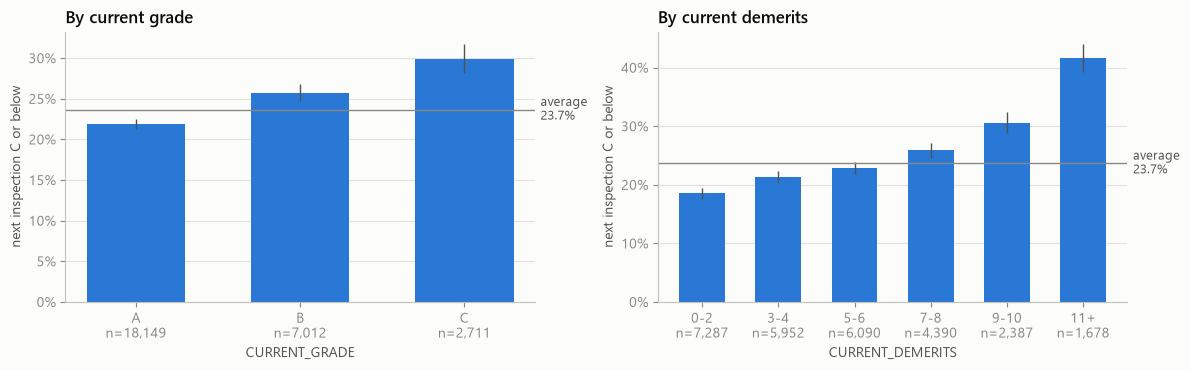

In [19]:
by_grade = rate_by(train, "CURRENT_GRADE")
by_current_dem = rate_by(train, pd.cut(train["CURRENT_DEMERITS"], [-1, 2, 4, 6, 8, 10, 100],
                                       labels=["0-2", "3-4", "5-6", "7-8", "9-10", "11+"]).rename("current demerits"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_rate(by_grade, "By current grade", xlabel="CURRENT_GRADE", ax=axes[0])
plot_rate(by_current_dem, "By current demerits", xlabel="CURRENT_DEMERITS", ax=axes[1])
fig.tight_layout()
save_fig(fig, "eda_current_status")
grade_vs_dem = train.groupby("CURRENT_GRADE").agg(rows=(TARGET, "size"),
                                                  median_inspection_demerits=("INSPECTION_DEMERITS", "median"),
                                                  median_current_demerits=("CURRENT_DEMERITS", "median"),
                                                  share_over_10_inspection_demerits=("INSPECTION_DEMERITS", lambda s: (s > 10).mean().round(3)))
print(f"rows used: grade {int(by_grade['n'].sum()):,}, current demerits {int(by_current_dem['n'].sum()):,}")
grade_vs_dem

**Interpretation**
- **Inspection type shows no clear difference:** re-inspections (24.0%, n = 1,713) and routine inspections (23.6%) are within each other's intervals (unadjusted p = 0.74), and "Other" has only 18 rows.
- **Current status does track the outcome:**
  - Grade A 21.9%, B 25.8%, C 29.9%.
  - Current demerits rise from 18.5% at 0–2 to 41.6% at 11 or more.
- **But the grade doesn't follow the SNHD cut-offs** (A 0–10, B 11–20, C 21–40).
  - Median inspection demerits are 9 for A and 12 for both B and C.
  - 41% of A-graded rows have more than 10 inspection demerits (B: 58%, C: 60%).
  - So what these columns measure, and when, is unclear.
- **For 03 and 04:** register both under a separate feature set, `current_status`. Model with and without them. Only keep them in the final model if the gain is meaningful *and* the timing concern is documented as an accepted risk. Don't use the inspection-type flag.

## 8. Restaurant attributes

same rate within ≤200 seats? unadjusted p = 0.58 | within >200 seats? unadjusted p = 0.16


,n,positives,rate,ci_low,ci_high,lift,design_effect
venue size,,,,,,,
>200 seats,13066,3998,0.306,0.298,0.314,1.29,1.00
≤200 seats,14970,2639,0.176,0.170,0.183,0.74,1.01


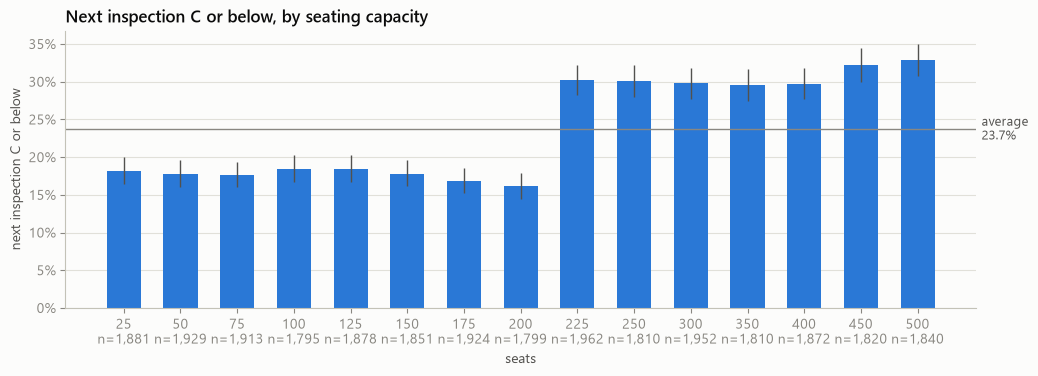

In [20]:
by_seats = rate_by(train, "restaurant_seating_capacity")
plot_rate(by_seats, "Next inspection C or below, by seating capacity", xlabel="seats")
save_fig(plt.gcf(), "eda_rate_by_seating")
small, large = train["restaurant_seating_capacity"].le(200), train["restaurant_seating_capacity"].gt(200)
print(f"same rate within ≤200 seats? unadjusted p = {homogeneity_p(train['restaurant_seating_capacity'].where(small)):.2f} | "
      f"within >200 seats? unadjusted p = {homogeneity_p(train['restaurant_seating_capacity'].where(large)):.2f}")
show(rate_by(train, large.map({True: ">200 seats", False: "≤200 seats"}).rename("venue size")))

≤200 seats                       >200 seats                      
                    n   rate ci_low ci_high          n   rate ci_low ci_high
violations                                                                  
3                2835  0.092  0.082   0.103       2495  0.223  0.207   0.240
4                3627  0.124  0.113   0.135       3188  0.247  0.233   0.262
5                2912  0.149  0.137   0.163       2587  0.294  0.277   0.312
6                2081  0.190  0.174   0.208       1787  0.309  0.288   0.331
7-8              2207  0.243  0.226   0.262       1812  0.378  0.356   0.401
9+               1306  0.430  0.403   0.457       1193  0.548  0.520   0.576

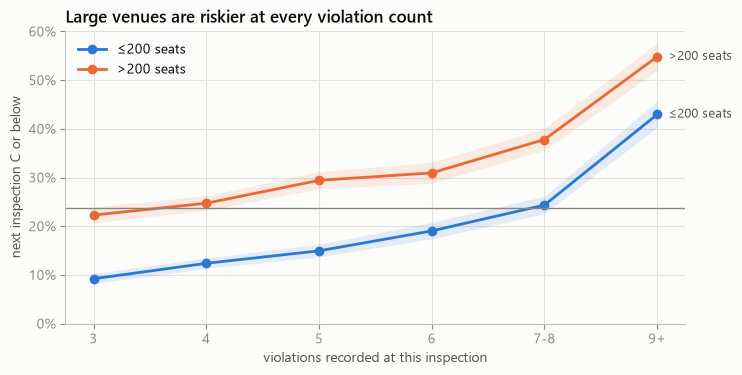

In [21]:
bands = pd.cut(train["n_violations"], [0, 3, 4, 5, 6, 8, 100], labels=["3", "4", "5", "6", "7-8", "9+"]).rename("violations")
small_t, large_t = rate_by(train[small], bands[small]), rate_by(train[large], bands[large])
plot_two_groups(small_t, large_t, "≤200 seats", ">200 seats",
                "Large venues are riskier at every violation count", "violations recorded at this inspection")
save_fig(plt.gcf(), "eda_seats_by_violations")
pd.concat({"≤200 seats": show(small_t)[["n", "rate", "ci_low", "ci_high"]],
           ">200 seats": show(large_t)[["n", "rate", "ci_low", "ci_high"]]}, axis=1)

**Interpretation**
- **Seating capacity is a step, not a slope.** Every capacity from 25 to 200 seats sits at 16–18%, and every capacity from 225 to 500 at 30–33%. There's no detectable difference *within* either side (unadjusted p = 0.58 and 0.16), but a near doubling across the 200-seat line (17.6% vs 30.6%).
- **The step adds to the violation effect rather than replacing it:** larger venues are about 12–15 points higher at every violation count, and the gap doesn't shrink as violations rise.
- **Caveat:** a step this clean is unusual in real data and may be an artifact of how this exercise's data was prepared. The pattern is still consistent and large.
- **For 03:** a binary `large_venue = seats > 200` describes the data better than raw seats. The combination of large venue and many violations is worth letting the model capture (trees do this naturally).

30 categories; 18 have fewer than 100 training rows (734 rows in total); missing category: 177 rows


,n,positives,rate,ci_low,ci_high,lift,design_effect
RESTAURANT_CATEGORY,,,,,,,
Restaurant,15889,3717,0.234,0.227,0.241,0.99,1.04
Bar / Tavern,4713,1159,0.246,0.234,0.259,1.04,1.05
Snack Bar,2415,581,0.241,0.224,0.258,1.02,1.00
Special Kitchen,2199,552,0.251,0.233,0.270,1.06,1.03
Buffet,453,65,0.143,0.112,0.182,0.61,1.17
Pantry,330,69,0.209,0.168,0.258,0.88,1.05
Portable Unit,315,67,0.213,0.168,0.265,0.90,1.17
Meat/Poultry/Seafood,271,59,0.218,0.173,0.271,0.92,1.00
Food Trucks / Mobile Vendor,160,42,0.262,0.196,0.342,1.11,1.16


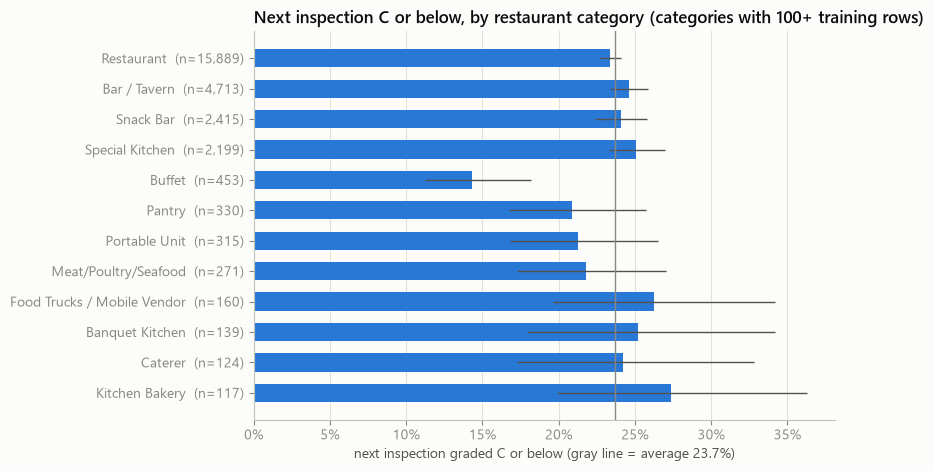

In [22]:
by_category = rate_by(train, "RESTAURANT_CATEGORY", min_n=100).sort_values("n", ascending=False)
plot_rate(by_category, "Next inspection C or below, by restaurant category (categories with 100+ training rows)",
          horizontal=True)
save_fig(plt.gcf(), "eda_rate_by_category")
all_categories = rate_by(train, "RESTAURANT_CATEGORY", min_n=1)
print(f"{len(all_categories)} categories; {int((all_categories['n'] < 100).sum())} have fewer than 100 training rows "
      f"({int(all_categories.loc[all_categories['n'] < 100, 'n'].sum())} rows in total); "
      f"missing category: {int(train['RESTAURANT_CATEGORY'].isna().sum())} rows")
show(by_category)

**Interpretation**
- **Most large categories look alike:** Restaurant (15,889 rows), Bar / Tavern, Snack Bar and Special Kitchen all sit within about 1.5 points of the 23.7% average.
- **Buffets are the clear exception at 14.3%** [11.2%, 18.2%] (n = 453), well below average.
- **Small categories aren't readable:** 18 of the 30 categories have fewer than 100 training rows. Some of them look extreme (Main Kitchen 7%, Bakery Sales 36%), but their intervals are wide.
- **For 03:** keep the category, but pool categories with fewer than 100 training rows into "Other" (decided on training counts), or use a simple buffet flag. Don't interpret the small categories.

In [23]:
restaurant_age = ((train[TIME_COL] - train["restaurant_open_date"]).dt.days / 365.25).rename("restaurant age (years)")
quintile_summary = {}
for name, values in [("employees", train["EMPLOYEE_COUNT"]), ("median employee age", train["MEDIAN_EMPLOYEE_AGE"]),
                     ("median employee tenure", train["MEDIAN_EMPLOYEE_TENURE"]), ("restaurant age", restaurant_age)]:
    t = rate_by(train, pd.qcut(values, 5, duplicates="drop").rename(name))
    quintile_summary[name] = pd.Series({"rows used": int(t["n"].sum()), "lowest quintile rate": round(t["rate"].min(), 3),
                                 "highest quintile rate": round(t["rate"].max(), 3),
                                 "unadjusted chi-square p": round(homogeneity_p(pd.qcut(values, 5, duplicates="drop")), 2)})
attributes = pd.DataFrame(quintile_summary).T
attributes.join(univariate_auc(train.assign(**{"restaurant age": restaurant_age}),
                               ["EMPLOYEE_COUNT", "MEDIAN_EMPLOYEE_AGE", "MEDIAN_EMPLOYEE_TENURE", "restaurant age"])
                .rename(index={"EMPLOYEE_COUNT": "employees", "MEDIAN_EMPLOYEE_AGE": "median employee age",
                               "MEDIAN_EMPLOYEE_TENURE": "median employee tenure"})[["auc"]])

,rows used,lowest quintile rate,highest quintile rate,unadjusted chi-square p,auc
employees,27784.0,0.229,0.246,0.34,0.497
median employee age,27781.0,0.229,0.243,0.31,0.500
median employee tenure,27787.0,0.231,0.245,0.51,0.502
restaurant age,27758.0,0.233,0.243,0.77,0.494


In [24]:
hours = rate_by(train, "restaurant_operating_hours").sort_values("rate")
print(f"operating hours: {len(hours)} schedules, {int(hours['n'].min()):,}-{int(hours['n'].max()):,} rows each; "
      f"rates {hours['rate'].min():.1%}-{hours['rate'].max():.1%}; unadjusted chi-square p = "
      f"{homogeneity_p(train['restaurant_operating_hours']):.3f}")
show(pd.concat([hours.head(3), hours.tail(3)]))[["n", "rate", "ci_low", "ci_high"]]

operating hours: 24 schedules, 1,033-1,286 rows each; rates 20.6%-26.5%; unadjusted chi-square p = 0.045


,n,rate,ci_low,ci_high
restaurant_operating_hours,,,,
Mon-Sun 11am-11pm,1084,0.206,0.182,0.231
Daily 10am-11pm,1033,0.213,0.189,0.240
Daily 12pm-12am,1175,0.216,0.193,0.241
Mon-Sun 10:30am-10:30pm,1207,0.262,0.237,0.288
"Mon-Thu 10am-9pm, Fri-Sat 10am-11pm, Sun 10am-9pm",1258,0.264,0.239,0.290
Mon-Sun 7am-11pm,1208,0.265,0.241,0.291


In [25]:
in_venue = (train["RESTAURANT_LOCATION"].ne(train["RESTAURANT_NAME"])
            .where(train["RESTAURANT_LOCATION"].notna()).map({True: "inside a venue", False: "standalone"}))
numbered = train["RESTAURANT_NAME"].str.contains(r"#\d", regex=True).map({True: "numbered (#)", False: "no number"})
zip_big = train["ZIP5"].where(train["ZIP5"].map(train["ZIP5"].value_counts()) >= 300)
location = pd.DataFrame({
    "city": {"groups": train["CITY"].nunique(), "unadjusted p": homogeneity_p(train["CITY"])},
    "ZIP (300+ rows each)": {"groups": zip_big.nunique(), "unadjusted p": homogeneity_p(zip_big)},
    "inside a venue vs standalone": {"groups": 2, "unadjusted p": homogeneity_p(in_venue)},
    "numbered (chain-like) name": {"groups": 2, "unadjusted p": homogeneity_p(numbered)},
}).T.round({"unadjusted p": 3})
print(location.to_string())
print(f"ZIPs with 300+ rows: rates {rate_by(train, zip_big)['rate'].min():.1%}-{rate_by(train, zip_big)['rate'].max():.1%}")
print(univariate_auc(train, ["LATITUDE", "LONGITUDE"])[["auc", "rows_used"]].to_string())
pd.concat({"venue": show(rate_by(train, in_venue.rename("g"))), "name": show(rate_by(train, numbered.rename("g")))})[
    ["n", "rate", "ci_low", "ci_high"]]

                              groups  unadjusted p
city                             6.0         0.656
ZIP (300+ rows each)            29.0         0.943
inside a venue vs standalone     2.0         0.262
numbered (chain-like) name       2.0         0.780
ZIPs with 300+ rows: rates 20.5%-26.5%
             auc  rows_used
column                     
LATITUDE   0.501      28027
LONGITUDE  0.500      28027


n   rate  ci_low  ci_high
      g                                            
venue inside a venue  13054  0.240   0.232    0.247
      standalone      14733  0.234   0.227    0.241
name  no number       22996  0.237   0.232    0.243
      numbered (#)     5040  0.235   0.223    0.247

**Interpretation**
- **Employees and restaurant age:** employee count, median employee age, median tenure and restaurant age show no clear association. Their quintile rates stay within 2 points, every univariate AUC is 0.49–0.51, and no test detects a difference (unadjusted p = 0.31–0.77).
- **Operating hours:** the 24 schedules range from 20.6% to 26.5% with about 1,000–1,300 rows each. The overall test is borderline (unadjusted p = 0.045) with 23 degrees of freedom, and the ordering has no sensible pattern (e.g. "24 hours" isn't extreme). With this many groups and tests, that's weak evidence.
- **Location:** city, ZIP, latitude/longitude, being inside a venue (casino, mall) and a chain-like numbered name show no clear signal. For example, 29 ZIPs with 300+ rows each range from 20.5% to 26.5% (unadjusted p = 0.94).
- **For 03:** these are candidates to drop. Record them as considered and rejected, with these numbers. If operating hours are kept at all, parse them into a few interpretable attributes and let cross-validation judge them, rather than one-hot encoding 24 schedules.

## 9. The added business columns

In [26]:
business = ["annual_customer_complaint_count", "foodborne_illness_count", "review_rating", "cleaning_station_count",
            "allergen_labeling_flag", "inspection_announced_flag", "safety_certification_flag"]
groupings = {c: train[c] for c in business}
groupings["annual_customer_complaint_count"] = quintiles(train["annual_customer_complaint_count"])
groupings["foodborne_illness_count"] = train["foodborne_illness_count"].clip(upper=5)  # mostly zeros
screen = univariate_auc(train, business)
screen["unadjusted chi-square p"] = [round(homogeneity_p(groupings[c]), 3) for c in screen.index]
flags = {c: show(rate_by(train, train[c].map({1: "yes", 0: "no"}).rename(c)))[["n", "rate", "ci_low", "ci_high"]]
         for c in ["allergen_labeling_flag", "inspection_announced_flag", "safety_certification_flag"]}
print(pd.concat(flags).to_string())
screen

                                                      n   rate  ci_low  ci_high
                          allergen_labeling_flag                               
allergen_labeling_flag    no                       8190  0.231   0.222    0.241
                          yes                     19846  0.239   0.233    0.245
inspection_announced_flag no                      20281  0.233   0.228    0.239
                          yes                      7755  0.245   0.236    0.255
safety_certification_flag no                      10509  0.243   0.235    0.251
                          yes                     17527  0.233   0.227    0.239


,auc,strength,rows_used,missing,direction,unadjusted chi-square p
column,,,,,,
annual_customer_complaint_count,0.510,0.510,28036,0,higher → more C,0.014
inspection_announced_flag,0.507,0.507,28036,0,higher → more C,0.039
safety_certification_flag,0.493,0.507,28036,0,higher → fewer C,0.053
cleaning_station_count,0.494,0.506,28036,0,higher → fewer C,0.050
allergen_labeling_flag,0.504,0.504,28036,0,higher → more C,0.181
review_rating,0.498,0.502,28036,0,higher → fewer C,0.162
foodborne_illness_count,0.501,0.501,28036,0,higher → more C,0.573


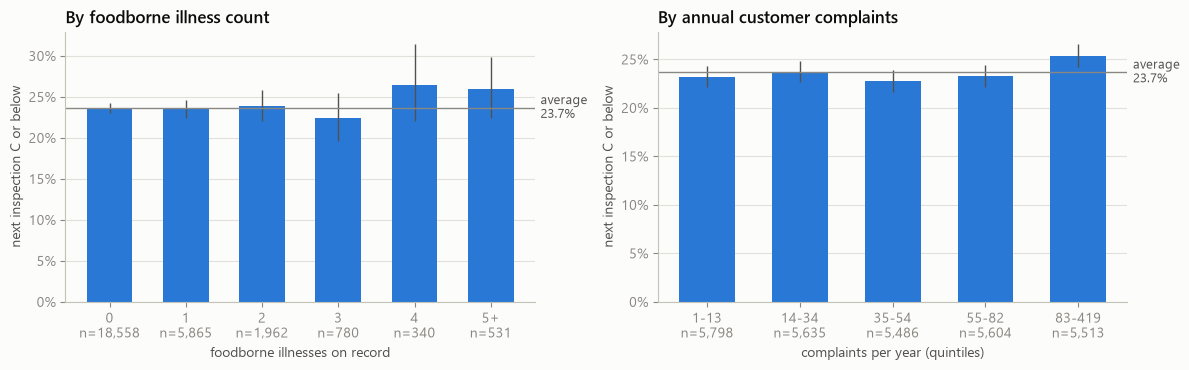

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_rate(rate_by(train, capped(train["foodborne_illness_count"], 5, "illness")),
          "By foodborne illness count", xlabel="foodborne illnesses on record", ax=axes[0])
plot_rate(rate_by(train, quintiles(train["annual_customer_complaint_count"]).rename("complaints")),
          "By annual customer complaints", xlabel="complaints per year (quintiles)", ax=axes[1])
fig.tight_layout()
save_fig(fig, "eda_business_columns")

**Interpretation**
- **No strong association, despite intuition:** complaints, foodborne illnesses, review rating, cleaning stations and the three flags all have univariate AUCs of 0.49–0.51.
  - Foodborne-illness counts of 0 to 3 all sit at 22–24%.
  - The higher counts (4, and 5 or more: 26.0–26.5%) have intervals that overlap the average.
- **Complaints are the clearest of the small effects:** the top quintile (83+ per year) is at 25.4% vs 22.8–23.7% for the rest (unadjusted p = 0.014). That's still only about 2 points, and the AUC is 0.51.
- **A few other small differences are at the edge of significance:** announced vs unannounced inspections 24.5% vs 23.3% (unadjusted p = 0.04), no safety certification 24.3% vs 23.3% (unadjusted p = 0.05), and cleaning stations (unadjusted p = 0.05, driven by the 2-station group).
  - These are differences of about 1 point.
  - With about two dozen tests in this notebook, one or two results near p ≈ 0.05 are expected by chance.
- **For 03:** exclude these by default and document the evidence. That's a useful finding for stakeholders: in this data, complaint and illness counts barely relate to the next grade. If anything, test them as one block in a 04 comparison, with complaints as the only one worth a closer look.

## 10. Time and repeat-restaurant structure

In [28]:
when = train[TIME_COL]
calendar = pd.DataFrame({
    "year": {"groups": when.dt.year.nunique(), "unadjusted p": homogeneity_p(when.dt.year)},
    "month": {"groups": when.dt.month.nunique(), "unadjusted p": homogeneity_p(when.dt.month)},
    "weekday": {"groups": when.dt.dayofweek.nunique(), "unadjusted p": homogeneity_p(when.dt.dayofweek)},
    "hour of day": {"groups": when.dt.hour.nunique(), "unadjusted p": homogeneity_p(when.dt.hour)},
}).T.round({"unadjusted p": 3})
hour_counts = when.dt.hour.value_counts()
print(f"inspections per hour of day: {hour_counts.min():,}-{hour_counts.max():,} (including {hour_counts.loc[[0, 1, 2, 3]].sum():,} "
      f"between midnight and 4 am)")
calendar

inspections per hour of day: 1,056-1,251 (including 4,466 between midnight and 4 am)


,groups,unadjusted p
year,7.0,0.389
month,12.0,0.473
weekday,7.0,0.984
hour of day,24.0,0.288


In [29]:
ordered = train.dropna(subset=[TIME_COL]).sort_values([GROUP_KEY, TIME_COL])
by_r = ordered.groupby(GROUP_KEY)
ordered["previous_target"] = by_r[TARGET].shift(1)
ordered["days_since_previous"] = (ordered[TIME_COL] - by_r[TIME_COL].shift(1)).dt.days
ordered["position"] = by_r.cumcount().clip(upper=3).map({0: "1st", 1: "2nd", 2: "3rd", 3: "4th+"})
print("days between consecutive training rows of a restaurant:",
      ordered["days_since_previous"].describe()[["count", "25%", "50%", "75%"]].round(0).to_dict())
pd.concat({
    "previous row's label": show(rate_by(ordered, ordered["previous_target"].map({0: "not C", 1: "C or below"}).rename("g"))),
    "position in the restaurant's history": show(rate_by(ordered, ordered["position"].rename("g"))),
})[["n", "rate", "ci_low", "ci_high"]]

days between consecutive training rows of a restaurant: {'count': 11940.0, '25%': 210.0, '50%': 476.0, '75%': 900.0}


n   rate  ci_low  ci_high
                                     g                                        
previous row's label                 C or below   2811  0.260   0.244    0.277
                                     not C        9129  0.228   0.219    0.237
position in the restaurant's history 1st         15842  0.238   0.232    0.245
                                     2nd          7122  0.242   0.232    0.252
                                     3rd          3182  0.228   0.214    0.243
                                     4th+         1636  0.224   0.204    0.245

**Interpretation**
- **No clear calendar effect:** year, month and weekday show no detectable association (unadjusted p = 0.39, 0.47, 0.98).
- **Hour of day looks synthetic:** inspections are spread almost evenly across all 24 hours, including about 4,500 between midnight and 4 am. That isn't how real inspections are scheduled, and the hour shows no clear signal (unadjusted p = 0.29). Calendar features are unlikely to help.
- **Repeat inspections are far apart and only mildly related:**
  - Consecutive rows of a restaurant are a median of 476 days apart, so the rows are a sample of each restaurant's history, not every visit.
  - When the previous row's next inspection was C or below, this row's rate is 26.0% (n = 2,811), vs 22.8% otherwise (n = 9,129). That's modest within-restaurant dependence, consistent with the small design effect.
  - A row's position in the restaurant's history makes no difference.
- **For 03 (low priority):** backward-looking history features, i.e. the count of earlier rows and the earlier rows' average violations. The previous row's label is known at prediction time only if that next inspection happened before this one. That's plausible here, but the data can't confirm it, so prefer history built from earlier *inspection results* (violations), not earlier labels.

## 11. Inspector comments

Comments are split into `//` fragments, and numbers are masked as `#` to form templates. Each template is classified into one of five kinds:
- **observation:** a food-safety finding, mostly in inspector shorthand;
- **process:** inspection administration (routine visit, photos, follow-up scheduled);
- **restated fact:** repeats one of the added business columns (seats, complaints, ratings, certification, …);
- **chatter:** the inspector's personal notes;
- **redacted remark:** contains `[REDACTED]`.

The classification lists are explicit and reviewable.

In [30]:
PROCESS = {
    "routine", "routine insp", "rtn visit", "re-insp f/u", "re-inspection insp", "photos in file", "see attach",
    "signed off", "# viol noted", "viol## noted", "tot dem #", "grade a posted", "grade b posted", "grade c posted",
    "ch#", "reinsp req #d", "reinsp not req", "re-visit confirmed", "expected follow-up visit", "f/u photos taken",
    "verbal warn issued", "permit posted ok",
}
RESTATED = {
    # seating
    "large capacity # seats", "seating over #", "#+ seat restaurant", "capacity appropriate", "over capacity concern",
    "small intimate space", "seating appropriate for ops",
    # complaints / reviews
    "# recent complaints", "recent complaint surge #", "customer complaints noted", "multiple complaints on file",
    "complaint history concerning", "low complaint count", "online rating #.#+", "customer ratings down",
    "negative reviews recent", "review feedback ok", "reviews are favorable", "review score declining",
    # restaurant age
    "established since #", "new establishment", "recently opened", "long operational history",
    "long-time establishment", "established operation",
    # cleaning stations
    "# cleaning stations on site", "only # cleaning station", "minimal cleaning stations",
    "sufficient cleaning infrastructure", "adequate cleaning stns", "cleaning inadequate",
    # foodborne illness
    "foodborne illness flagged", "no fi incidents reported", "potential fi link", "past fi concern",
    "foodborne risk elevated", "no acute fi risk",
    # allergen labeling
    "allergen labels present", "allergen labels missing", "allergen compliance gap", "allergen handling concerns",
    "major allergen labeling gaps", "allergen awareness good",
    # certification / training
    "safety cert on file", "no safety certification", "certification expired", "staff cert on file ok",
    "safety training documented", "training gap noted",
    # announced inspection
    "surprise inspection", "inspection unannounced", "announced inspection visit", "advance notice given",
    # volume
    "busy high-volume operation", "high-volume operation",
}
OBSERVATION = {
    # handwashing
    "no soap @ front hws", "hws blocked by cart", "hw stn used for storage", "hwash stn blocked", "hws no ppr twls",
    "no hot water handsink", "diligent handwashing observed",
    # critical items / corrections
    "priority viol-f/u", "**crit-corrected**", "crit item, cos", "corrected during insp", "cos",
    # temperatures / thermometers
    "hot hold @ #f ok", "hot hold @ #f", "wic @ #f (>#)", "wic @ #f", "ric @ #f", "cold hold @ #f", "tcs @ #f on line",
    "tcs left out ~#hr", "tcs temped ok", "phf ok", "temperatures all in range", "stem thermo calib ok",
    "no thermo in ric ##",
    # management / staff
    "pic ok", "pic uncoop", "pic coop", "pic new mgr", "cert fpm exp #/#", "no hh cards x#", "emp drink on prep tbl",
    # cross-contamination / storage / chemicals
    "raw chicken over produce", "raw over rte wic", "raw chx over rte", "uncovered pans in ric", "chem nr food prep",
    "dry stg orderly", "scoops no handle", "to-go cups on floor",
    # sanitizing
    "sani low-retested", "dish mach no sani", "#-comp not set up", "#-comp sink ok", "quat @ #ppm low",
    "sani @ #ppm quat", "sani bkt #ppm-refilled", "chlor test kit missing",
    # pests
    "flies at bar drain", "gnats @ bar drain", "vermin harborage", "cockroach egg casings", "roaches near cook line",
    "ant traps", "glue traps empty", "rodent droppings dry storage", "droppings nr dry stg",
    # sewage / plumbing
    "sewage backup floor drain", "raw sewage odor", "grease trap due",
    # food condition / labeling
    "meat slicer moldy", "mold in ice machine", "ice mach clean", "expired food on line", "date mk missing",
    "no date mk on prep", "thorough date marking", "labels missing bulk bins",
    # overall condition
    "well maintained facility", "meticulous", "impeccably clean kitchen", "spotless prep area", "pristine dish area",
    "exemplary food handling",
    # facility / equipment
    "mop bleacher", "mop sink ok", "back dock ok", "flr drk btwn cook line", "ceiling stain wic", "grout coming up",
    "flr tile cracked prep", "gaskets torn wic", "hood filters gunky", "grease buildup hood", "#-dr reach-in ok",
    # regulatory
    "nca compliant", "tphc log spotty",
}


def classify(template):
    """Kind of a comment template (numbers already masked as #)."""
    if "[redacted]" in template:
        return "redacted remark"
    if template in PROCESS:
        return "process"
    if template in RESTATED:
        return "restated fact"
    if template in OBSERVATION:
        return "observation"
    return "chatter"


def template_of(fragment):
    return re.sub(r"\d+", "#", fragment)


blank = train["comment_fragments"].map(len).eq(0)
print("blank comments:")
print(show(rate_by(train, blank.map({True: "blank", False: "has a comment"}).rename("comment")))[
    ["n", "rate", "ci_low", "ci_high"]].to_string())

templates = train["comment_fragments"].map(lambda frags: sorted({template_of(f) for f in frags}))
long = pd.DataFrame({"template": templates, TARGET: train[TARGET], GROUP_KEY: train[GROUP_KEY]}).explode("template").dropna()
long["kind"] = long["template"].map(classify)
kinds = long.drop_duplicates("template").groupby("kind").size().rename("templates").to_frame()
kinds["share of fragments"] = long["kind"].value_counts(normalize=True).round(3)
print(f"\n{long['template'].nunique()} distinct templates in training comments")
kinds.sort_values("templates", ascending=False)

blank comments:
                   n   rate  ci_low  ci_high
comment                                     
blank           2272  0.254   0.236    0.272
has a comment  25764  0.235   0.230    0.241



307 distinct templates in training comments


,templates,share of fragments
kind,,
chatter,121,0.176
observation,87,0.411
restated fact,55,0.204
process,22,0.172
redacted remark,22,0.037


,templates,share_beyond_chance,lowest_rate,highest_rate
kind,,,,
observation,85,0.400,0.173,0.320
process,22,0.136,0.215,0.297
chatter,90,0.044,0.206,0.264
restated fact,55,0.055,0.217,0.262
redacted remark,22,0.000,0.211,0.249


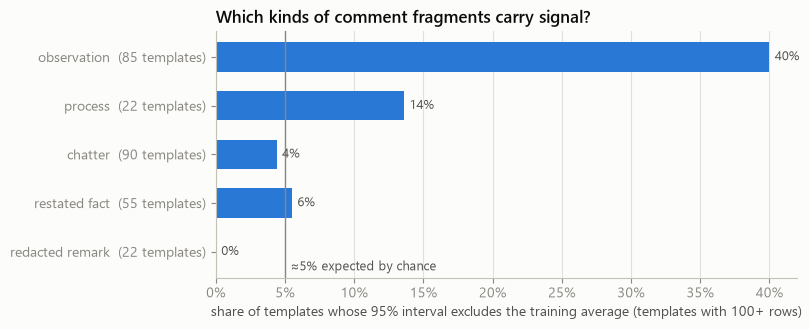

In [31]:
per_template = pd.concat({kind: rate_by(sub, "template", min_n=100) for kind, sub in long.groupby("kind")},
                         names=["kind", "template"]).reset_index()
per_template["interval excludes the average"] = (per_template["ci_low"] > BASE_RATE) | (per_template["ci_high"] < BASE_RATE)
by_kind = per_template.groupby("kind").agg(templates=("template", "size"),
                                           share_beyond_chance=("interval excludes the average", "mean"),
                                           lowest_rate=("rate", "min"), highest_rate=("rate", "max")).round(3)
order = ["observation", "process", "chatter", "restated fact", "redacted remark"]
by_kind = by_kind.reindex(order)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(np.arange(len(by_kind)), by_kind["share_beyond_chance"], height=0.6, color=SERIES[0])
ax.set_yticks(np.arange(len(by_kind)), [f"{k}  ({n} templates)" for k, n in zip(by_kind.index, by_kind["templates"])])
ax.invert_yaxis()
ax.axvline(0.05, color=MUTED, linewidth=1)
ax.annotate("≈5% expected by chance", xy=(0.05, 0), xycoords=("data", "axes fraction"), xytext=(4, 3),
            textcoords="offset points", va="bottom", color=INK_2, fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.grid(axis="y", visible=False)
ax.set(title="Which kinds of comment fragments carry signal?",
       xlabel="share of templates whose 95% interval excludes the training average (templates with 100+ rows)")
for i, v in enumerate(by_kind["share_beyond_chance"]):
    ax.annotate(f"{v:.0%}", xy=(v, i), xytext=(4, 0), textcoords="offset points", va="center", color=INK_2, fontsize=9)
save_fig(fig, "eda_comment_kinds")
by_kind

In [32]:
observed = per_template[per_template["kind"].eq("observation")].sort_values("rate")
cols = ["template", "n", "rate", "ci_low", "ci_high", "lift"]
print("Observation templates with the lowest and highest rates (training rows, 100+ rows each):")
pd.concat([show(observed.head(8))[cols], show(observed.tail(10))[cols]])

Observation templates with the lowest and highest rates (training rows, 100+ rows each):


,template,n,rate,ci_low,ci_high,lift
167,temperatures all in range,1765,0.173,0.156,0.192,0.73
111,exemplary food handling,1837,0.174,0.157,0.192,0.73
138,no date mk on prep,574,0.178,0.149,0.211,0.75
162,spotless prep area,1937,0.179,0.163,0.197,0.76
131,labels missing bulk bins,613,0.183,0.154,0.215,0.77
172,well maintained facility,3692,0.187,0.174,0.200,0.79
168,thorough date marking,1809,0.191,0.174,0.210,0.81
135,mop bleacher,3064,0.193,0.179,0.207,0.81
134,mold in ice machine,2502,0.271,0.254,0.288,1.14
156,roaches near cook line,1181,0.285,0.259,0.311,1.20


rows with a pest/sewage note: 15,625 (56%)


no note        pest/sewage note       
                 n   rate                n   rate
violations                                       
3             2437  0.131             2893  0.172
4             3060  0.152             3755  0.206
5             2433  0.186             3066  0.243
6             1715  0.208             2153  0.275
7-8           1732  0.262             2287  0.336
9+            1033  0.422             1466  0.531

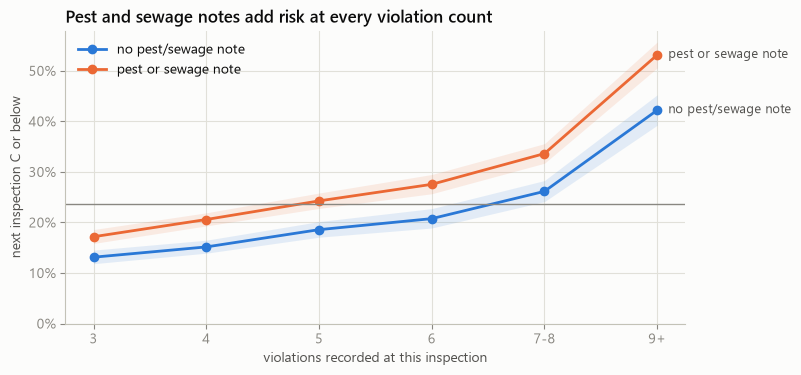

In [33]:
PEST_SEWAGE = r"roach|flies|gnats|ant traps|rodent|droppings|vermin|sewage"
pest = train["comment_fragments"].map(lambda frags: any(re.search(PEST_SEWAGE, f) for f in frags))
with_pest = rate_by(train[pest], bands[pest])
without_pest = rate_by(train[~pest], bands[~pest])
plot_two_groups(without_pest, with_pest, "no pest/sewage note", "pest or sewage note",
                "Pest and sewage notes add risk at every violation count", "violations recorded at this inspection")
save_fig(plt.gcf(), "eda_pests_by_violations")
print(f"rows with a pest/sewage note: {int(pest.sum()):,} ({pest.mean():.0%})")
pd.concat({"no note": show(without_pest)[["n", "rate"]], "pest/sewage note": show(with_pest)[["n", "rate"]]}, axis=1)

**Interpretation**
- **Blank comments:** 8.1% of rows have no comment, with a slightly higher rate (25.4% [23.6, 27.2]) than rows with one (23.5%). That's a small effect, possibly worth a "no comment" flag.
- **Only observation fragments carry signal.** Of the 85 observation templates with 100+ rows, **40%** have intervals that exclude the average. For chatter, restated facts and redacted remarks the share is 0–6%, which is about what chance alone produces (≈5%).
  - The few process templates beyond chance are `grade a posted` / `grade c posted`, which simply restate `CURRENT_GRADE`, and `ch#`, a constant code (`ch555`) with no interpretable meaning.
  - This supports dropping chatter, restated facts and redacted remarks before building comment features.
- **Which observations matter:**
  - Pests and sewage (cockroach egg casings, flies at the bar drain, sewage odor or backup, ants, roaches) and critical items corrected on site sit at 28–32%.
  - Positive notes ("temperatures all in range", "exemplary food handling", "spotless prep area", "well maintained facility") sit at 17–19%.
- **This signal is new information, not a restatement of the violations.** Pest or sewage notes appear on 56% of training rows. Within every violation-count band, rows with one are 4–11 points higher (e.g. 13.1% vs 17.2% at 3 violations, 42.2% vs 53.1% at 9 or more).
- **For 03:** comment features from observation fragments only, i.e. pest/sewage, critical-item notes and positive-condition notes. Map them to regulation topics with the acronym lookup and the corpus. Ignore the rest.

In [34]:
C = train["Comments"].str.lower()
number = lambda pattern: C.str.extract(pattern)[0].astype(float)
seats_said = number(r"large capacity (\d+) seats")
year_said = number(r"established since (\d{4})")
complaints_said = number(r"(\d+) recent complaints")
rating_said = number(r"online rating (\d\.\d)\+")
stations_said = number(r"(\d) cleaning stations on site")


def agreement(mask, consistent, base):
    return {"rows": int(mask.sum()), "consistent with the column": round(consistent[mask].mean(), 3),
            "expected if unrelated": round(base, 3)}


def chance_equal(said, real):
    """Probability the stated and real values match if they were unrelated."""
    p_said, p_real = said.dropna().value_counts(normalize=True), real.dropna().value_counts(normalize=True)
    return float((p_said * p_real.reindex(p_said.index).fillna(0)).sum())


seats_big = train["restaurant_seating_capacity"].gt(200)
said_big = seats_said.dropna().gt(200).mean()
open_year = train["restaurant_open_date"].dt.year
checks = {
    "'large capacity N seats': N on the same side of 200 as the real capacity":
        agreement(seats_said.notna(), seats_said.gt(200).eq(seats_big),
                  seats_big.mean() * said_big + (1 - seats_big.mean()) * (1 - said_big)),
    "'established since YYYY' = real opening year":
        agreement(year_said.notna(), year_said.eq(open_year), chance_equal(year_said, open_year)),
    "'N recent complaints' = complaint count":
        agreement(complaints_said.notna(), complaints_said.eq(train["annual_customer_complaint_count"]),
                  chance_equal(complaints_said, train["annual_customer_complaint_count"])),
    "'online rating X+': real rating ≥ X":
        agreement(rating_said.notna(), train["review_rating"].ge(rating_said),
                  rating_said.dropna().map(lambda x: train["review_rating"].ge(x).mean()).mean()),
    "'N cleaning stations on site' = real count":
        agreement(stations_said.notna(), stations_said.eq(train["cleaning_station_count"]),
                  chance_equal(stations_said, train["cleaning_station_count"])),
}
for phrase, col, value in [("allergen labels present", "allergen_labeling_flag", 1), ("no safety certification", "safety_certification_flag", 0),
                           ("surprise inspection", "inspection_announced_flag", 0), ("advance notice given", "inspection_announced_flag", 1)]:
    has = C.str.contains(re.escape(phrase), na=False)
    checks[f"'{phrase}' matches {col}"] = agreement(has, train[col].eq(value), train[col].eq(value).mean())
pd.DataFrame(checks).T

,rows,consistent with the column,expected if unrelated
'large capacity N seats': N on the same side of 200 as the real capacity,1894.0,0.487,0.491
'established since YYYY' = real opening year,1889.0,0.011,0.014
'N recent complaints' = complaint count,1834.0,0.005,0.002
'online rating X+': real rating ≥ X,1973.0,0.385,0.403
'N cleaning stations on site' = real count,1879.0,0.194,0.203
'allergen labels present' matches allergen_labeling_flag,1942.0,0.725,0.708
'no safety certification' matches safety_certification_flag,1844.0,0.362,0.375
'surprise inspection' matches inspection_announced_flag,1932.0,0.727,0.723
'advance notice given' matches inspection_announced_flag,1853.0,0.278,0.277


In [35]:
hot_ok = number(r"hot hold @ (\d+)f ok")
cold = C.str.findall(r"(?:wic|ric|cold hold|tcs) @ (\d+)f").explode().dropna().astype(float)
quat = C.str.extract(r"quat @ (\d+)ppm low")[0].dropna()
print(f"'hot hold @ NF ok': {int(hot_ok.notna().sum()):,} readings, {int((hot_ok < 135).sum()):,} below the 135°F rule")
print(f"cold-holding readings: {len(cold):,}, {int((cold > 41).sum()):,} above the 41°F rule")
print(f"'quat @ Nppm low': {len(quat):,} readings, all at {sorted(quat.unique())} ppm (inside the 150-400 ppm range)")

acronyms = pd.read_csv(RAW / "inspector_acronym_lookup.csv", dtype=str)
keys = sorted({k.strip().lower() for a in acronyms["Acronym"] for k in a.split(" / ")}, key=len, reverse=True)
acronym_re = re.compile(r"(?<![\w/-])(" + "|".join(map(re.escape, keys)) + r")(?![\w/-])")
fragments = train["comment_fragments"].explode().dropna()
kinds_of = fragments.map(lambda f: classify(template_of(f)))
obs_fragments = fragments[kinds_of.eq("observation")]
found = pd.Series([m for f in fragments for m in acronym_re.findall(f)]).value_counts()
print(f"\nobservation fragments using at least one lookup acronym: {obs_fragments.map(lambda f: bool(acronym_re.search(f))).mean():.0%}")
print("most used:", found.head(12).to_dict())
print("lookup entries never used in training comments:", sorted(set(keys) - set(found.index)))

'hot hold @ NF ok': 4,277 readings, 3,020 below the 135°F rule
cold-holding readings: 15,203, 8,064 above the 41°F rule
'quat @ Nppm low': 1,915 readings, all at ['150'] ppm (inside the 150-400 ppm range)



observation fragments using at least one lookup acronym: 59%
most used: {'viol': 26129, 'wic': 14265, 'pic': 13629, 'hws': 11743, 'prep': 10960, 'sani': 10707, 'f/u': 8331, 'tcs': 8302, 'ric': 7474, 'cos': 6615, 'rtn': 6508, 'rte': 5614}
lookup entries never used in training comments: ['cfpm', 'dem', 'haccp', 'hh card', 'nciaa', 'nov', 'ppm', 'rif', 'wi', 'wif']


In [36]:
leak_watch = ["re-visit confirmed", "expected follow-up visit", "reinsp req #d", "reinsp not req", "f/u photos taken",
              "verbal warn issued", "grade a posted", "grade b posted", "grade c posted"]
show(per_template.set_index("template").loc[leak_watch, ["kind", "n", "rate", "ci_low", "ci_high", "lift"]])

,kind,n,rate,ci_low,ci_high,lift
template,,,,,,
re-visit confirmed,process,1851,0.220,0.202,0.239,0.93
expected follow-up visit,process,1864,0.222,0.203,0.241,0.94
reinsp req #d,process,1895,0.236,0.218,0.256,1.00
reinsp not req,process,1815,0.227,0.208,0.247,0.96
f/u photos taken,process,1896,0.225,0.207,0.245,0.95
verbal warn issued,process,1914,0.243,0.225,0.263,1.03
grade a posted,process,5653,0.215,0.204,0.225,0.91
grade b posted,process,2164,0.241,0.223,0.260,1.02
grade c posted,process,838,0.297,0.267,0.329,1.26


**Interpretation**
- **Restated facts contradict the structured columns.**
  - A comment's "large capacity N seats" falls on the same side of 200 seats as the real capacity about as often as chance would give.
  - "Established since YYYY" matches the real opening year in about 1% of rows, and complaint counts essentially never match.
  - Flag phrases ("allergen labels present", "surprise inspection") agree with the flags at the base rate.
  - Use the structured columns, never these phrases.
- **The inspector's shorthand also contradicts itself:**
  - 3,020 of 4,277 "hot hold @ N°F ok" readings are below the 135°F rule.
  - About half of the cold-holding readings are above 41°F.
  - Every "quat low" reading is 150 ppm, which is inside the acceptable range.
  - So the temperature numbers aren't reliable features.
- **Shorthand coverage:** 59% of observation fragments use at least one lookup acronym (WIC, PIC, HWS, TCS, RIC, COS, …), so expanding them with the lookup helps map fragments to regulation topics in 03.
  - Some lookup entries never appear (e.g. HACCP, RIF, WIF).
  - Others are missed by a whole-word match: `PPM` is glued to numbers (`150ppm`), and `HH card` appears as `hh cards`. 03's expansion should allow for both.
- **No sign of leakage:**
  - Fragments about future visits ("re-visit confirmed", "expected follow-up visit", "reinsp req 10d", "reinsp not req") are all at the average.
  - Nothing in the comments describes the *next* inspection's result.
  - The "grade X posted" fragments restate `CURRENT_GRADE` and inherit its timing caveat (section 7), so they belong in the `current_status` group, not in comment features.

## 12. Redundancy between candidate predictors

Spearman r
n_violations       demerits_all_codes              0.83
critical_count     demerits_all_codes              0.79
                   worst_rank                      0.72
n_violations       INSPECTION_DEMERITS             0.67
demerits_all_codes INSPECTION_DEMERITS             0.57
critical_count     first_violation_demerits        0.57
worst_rank         demerits_all_codes              0.54
n_violations       critical_count                  0.52

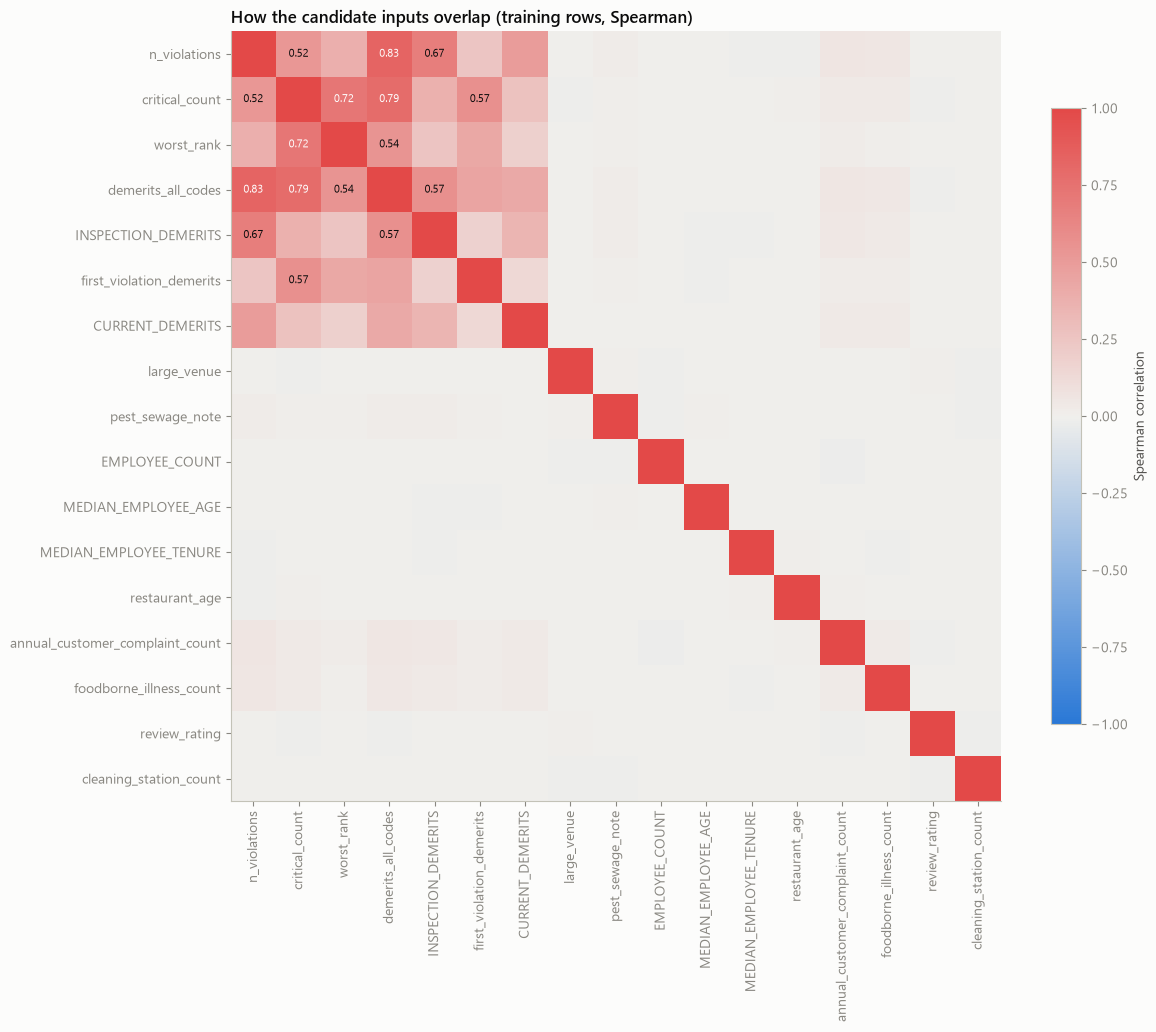

In [37]:
candidates_numeric = train.assign(**{
    "demerits_all_codes": dem_all, "critical_count": critical, "worst_rank": worst.map({v: k for k, v in RANK_NAME.items()}),
    "large_venue": large.astype(int), "pest_sewage_note": pest.astype(int), "restaurant_age": restaurant_age,
})
heat_cols = ["n_violations", "critical_count", "worst_rank", "demerits_all_codes", "INSPECTION_DEMERITS",
             "first_violation_demerits", "CURRENT_DEMERITS", "large_venue", "pest_sewage_note", "EMPLOYEE_COUNT",
             "MEDIAN_EMPLOYEE_AGE", "MEDIAN_EMPLOYEE_TENURE", "restaurant_age", "annual_customer_complaint_count",
             "foodborne_illness_count", "review_rating", "cleaning_station_count"]
fig, corr = plot_corr(candidates_numeric, heat_cols, "How the candidate inputs overlap (training rows, Spearman)")
save_fig(fig, "eda_correlation")
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().dropna()
pairs[pairs.abs() >= 0.5].sort_values(ascending=False).round(2).rename("Spearman r").to_frame()

**Interpretation**
- **The violation measures overlap heavily.**
  - The code-implied demerit total correlates 0.83 with `n_violations` and 0.79 with the critical count. The critical count and worst severity correlate 0.72.
  - `INSPECTION_DEMERITS` overlaps less (0.57 with the code total).
- **The rest is nearly independent:** seating, employee and business columns are essentially uncorrelated with each other and with the violation measures.
- **The pest/sewage note is almost uncorrelated with the violation measures,** which matches section 11's finding that it's new information.
- **For 03:** within the violation group, keep a small set:
  - `n_violations`;
  - the critical count or worst severity;
  - the IHH flag;
  - optionally the code total or `INSPECTION_DEMERITS`.
  Confirm with the redundancy check and cross-validation rather than keeping all of them. The other groups don't need redundancy pruning.

## 13. Findings → features (input for `03_features.ipynb`)

| # | Finding (training rows) | Evidence | Proposed feature or decision |
|---|---|---|---|
| 1 | The C-or-below rate climbs steadily with the violation count: 15.3% at 3 to 71.3% at 15+ | `eda_rate_by_violations` | `n_violations` as a number (authoritative count; 6 rows stay missing) |
| 2 | Worst severity separates risk: Non-Major 10.5%, Major 14.4%, Critical 27.5%, IHH 29.7% | `eda_rate_by_severity` | Worst-severity rank from complete lists, plus `violation_list_complete` |
| 3 | The critical count is the strongest count (14.4% at 0 to 57.5% at 5+); major and non-major counts mostly track the total | `eda_rate_by_severity`, counts table | Critical count (complete lists); test major and non-major counts for added value only |
| 4 | A confirmed IHH raises the rate (29.8% vs 23.3%) despite 0 demerits; 238 rows unknown | IHH table | Three-state IHH flag: 1 if confirmed, 0 only with a complete list, otherwise missing |
| 5 | Demerit measures disagree (recorded vs code total r = 0.57); code total AUC 0.635, recorded 0.604, first-three 0.590 | AUC table, `eda_correlation` | Code-implied total (complete lists); test `INSPECTION_DEMERITS` for added value; drop `TOTAL_MAPPED_DEMERITS` |
| 6 | Seating is a step: 17.6% at ≤200 seats vs 30.6% above, flat within each side, adding about 12–15 points at every violation count | `eda_rate_by_seating`, `eda_seats_by_violations` | `large_venue = seats > 200` instead of raw seats |
| 7 | Current grade and current demerits track the outcome (A 21.9% to C 29.9%; 18.5% to 41.6%), but their timing is unknown and the grades don't follow SNHD cut-offs | `eda_current_status` | Separate `current_status` feature set; compare with and without in 04 (leakage risk stays documented) |
| 8 | Buffets are lower (14.3%, n = 453); other large categories are close to average; 18 categories have fewer than 100 rows | `eda_rate_by_category` | Category with fewer than 100 training rows pooled into "Other" (or a buffet flag) |
| 9 | Pest and sewage notes add 4–11 points within every violation band; critical-item notes are high, positive notes are low | `eda_pests_by_violations`, observation table | Comment flags from observation fragments only: pest/sewage, critical item corrected, positive condition |
| 10 | Only observation fragments carry signal (40% beyond chance vs 0–6% for chatter, restated facts and redacted remarks) | `eda_comment_kinds` | Drop chatter, redacted remarks and restated facts before building comment features; map observations to corpus topics |
| 11 | Restated facts in comments contradict the structured columns; temperature readings are inconsistent with their "ok" / "low" labels | contradiction table | Never use restated-fact phrases or temperature numbers as features |
| 12 | Blank comments: 8.1% of rows, slightly higher rate (25.4%) | blank-comment table | Optional `comment_missing` flag |
| 13 | Complaints, illness counts, ratings, cleaning stations and the flags show no meaningful association (AUC 0.49–0.51). The largest is complaints: the top quintile is 2 points higher (unadjusted p = 0.014); the others are about 1 point at unadjusted p ≈ 0.04–0.05 | business table, `eda_business_columns` | Exclude by default, documented as considered; optional block test in 04 (complaints first) |
| 14 | Employee attributes, restaurant age, location and inspection type show no clear association; operating hours are borderline (unadjusted p = 0.045 over 24 groups) with no pattern | restaurant tables | Exclude by default; operating hours only as a few parsed attributes, if at all |
| 15 | No clear time trend (yearly unadjusted p = 0.39); hour of day is spread evenly over 24 hours (synthetic); weak repeat dependence (26.0% vs 22.8%) | `eda_target_by_quarter`, repeat table | No calendar features; optional backward-looking history features from earlier violations, not earlier labels |

**Decisions left for 03:**
1. Which overlapping violation measures to keep, using the redundancy check and cross-validation.
2. The pooling threshold for small categories (proposed: fewer than 100 training rows).
3. The topic-similarity threshold and hand overrides for mapping observation fragments to corpus topics, and whether to add a text (TF-IDF) feature on top of the flags.
4. How to parse operating hours, if they're used at all.
5. Whether to build history features.
6. How to register `current_status` so 04 can run the with/without comparison.

## 14. Readiness checks

In [38]:
reloaded = pd.read_csv(CLEAN / "split.csv", index_col="row")
checks = {
    "split.csv saved, aligned to the cleaned rows (row number and restaurant ID)":
        reloaded.index.equals(split_table.index) and reloaded[GROUP_KEY].equals(split_table[GROUP_KEY]),
    "split.csv reproduces the documented policy (seed 42, 20% of restaurants)": reloaded["split"].equals(split_table["split"]),
    "no restaurant in both training and holdout": len(overlap) == 0,
    "this notebook analysed training rows only": train.index.equals(split.index[split.eq("train")]),
    "every row assigned to exactly one set": split.isin(["train", "holdout"]).all() and len(split) == N_ROWS_ALL,
    "all figures saved": all((FIG / f"{name}.png").exists() for name in SAVED_FIGURES) and len(SAVED_FIGURES) >= 10,
}
for name, ok in checks.items():
    print(("✅ " if ok else "❌ ") + name)
print("\nfigures:", ", ".join(sorted(set(SAVED_FIGURES))))
assert all(checks.values()), "a readiness check failed"

✅ split.csv saved, aligned to the cleaned rows (row number and restaurant ID)
✅ split.csv reproduces the documented policy (seed 42, 20% of restaurants)
✅ no restaurant in both training and holdout
✅ this notebook analysed training rows only
✅ every row assigned to exactly one set
✅ all figures saved

figures: eda_business_columns, eda_comment_kinds, eda_correlation, eda_current_status, eda_pests_by_violations, eda_rate_by_category, eda_rate_by_inspection_demerits, eda_rate_by_seating, eda_rate_by_severity, eda_rate_by_violations, eda_seats_by_violations, eda_target_by_quarter
